# Analyse de la Biomasse du Blé Dur — Modélisation par IA
## Fusion de données in-situ et satellitaires
### Variétés Amina1 et Fanaye1 — Vallée du Fleuve Sénégal (Fanaye & N'Diol)

**Pipeline complet :**
- ✅ Sélection des variables (VIF + corrélation) — suppression des redondances NDVI/spectraux
- ✅ Vérification du data leakage (split temporel systématique)
- ✅ Entraînement Random Forest, XGBoost, LSTM
- ✅ Diagnostic surapprentissage (train vs test, courbes loss)
- ✅ Graphiques Observé vs Prédit & résidus
- ✅ Validation croisée phénologique (5 folds)
- ✅ Sauvegarde des modèles optimaux (.pkl / .keras)


---
## Partie 0 — Installation et chargement des données

In [ ]:
!pip install -q xgboost shap openpyxl statsmodels

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import os
import warnings

import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import joblib

import shap
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 10

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

model_colors = {'RandomForest': '#1f77b4', 'XGBoost': '#ff7f0e', 'LSTM': '#9467bd'}

print("Librairies chargées.")
print(f"TensorFlow: {tf.__version__} | XGBoost: {xgb.__version__}")

Librairies chargées.
TensorFlow: 2.20.0 | XGBoost: 3.2.0


In [2]:
import os
import pandas as pd

# ── Chargement du fichier de données ──────────────────────────────────────────
DATA_PATH = '/content/base_cleaned_harmonized (1).xlsx'

if not os.path.exists(DATA_PATH):
    # Tentative Google Colab
    try:
        from google.colab import files
        print("Sélectionnez le fichier Excel de données :")
        uploaded = files.upload()
        DATA_PATH = list(uploaded.keys())[0]
    except ImportError:
        raise FileNotFoundError(
            f"Fichier '{DATA_PATH}' introuvable. "
            "Placez-le dans le même répertoire que ce notebook."
        )

df = pd.read_excel(DATA_PATH)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['site', 'variete', 'date']).reset_index(drop=True)
df['das'] = df.groupby(['site', 'variete'])['date'].transform(
    lambda x: (x - x.min()).dt.days
)

print(f"Données chargées. Shape : {df.shape}")
print("\nPériode couverte par groupe :")
print(df.groupby(['site', 'variete'])['date'].agg(['min', 'max', 'count']))

Données chargées. Shape : (426, 34)

Période couverte par groupe :
                      min        max  count
site   variete                             
Fanaye Amina1  2026-01-13 2026-04-24    102
       Fanaye1 2026-01-13 2026-04-24    102
N'Diol Amina1  2026-01-02 2026-04-24    111
       Fanaye1 2026-01-02 2026-04-24    111


In [3]:
# ── Définition des groupes et colonnes à exclure de la modélisation ──────────
COLS_TO_EXCLUDE = ['date', 'site', 'variete', 'biomasse_cum']

GROUPS = [
    ('Fanaye_Amina1',  'Fanaye',  'Amina1'),
    ('Fanaye_Fanaye1', 'Fanaye',  'Fanaye1'),
    ('NDiol_Amina1',   "N'Diol",  'Amina1'),
    ('NDiol_Fanaye1',  "N'Diol",  'Fanaye1'),
]

all_results          = []
feature_importance_store = {}
predictions_store    = {}

print("Groupes définis :", [g[0] for g in GROUPS])

Groupes définis : ['Fanaye_Amina1', 'Fanaye_Fanaye1', 'NDiol_Amina1', 'NDiol_Fanaye1']


---
## Partie 1 — Sélection des variables (réduction de la multicolinéarité)

### Justification

Les indices spectraux optiques (NDVI, SAVI, CIRe, LAI, FAPAR) sont **quasi-parfaitement corrélés**
entre eux (r > 0.99). Les utiliser tous ensemble n'apporte aucune information supplémentaire aux modèles
mais gonfle l'espace feature, dilue les importances et ralentit l'entraînement.

De même, les variables sol (EC, N, P, K, salinité) présentent une **corrélation parfaite** (r = 1.0)
et les variables de température/humidité se chevauchent fortement.

**Stratégie :** analyse VIF (Variance Inflation Factor) + corrélation avec la cible →
garder **1 représentant par groupe redondant**, en privilégiant la variable la plus corrélée à la biomasse.


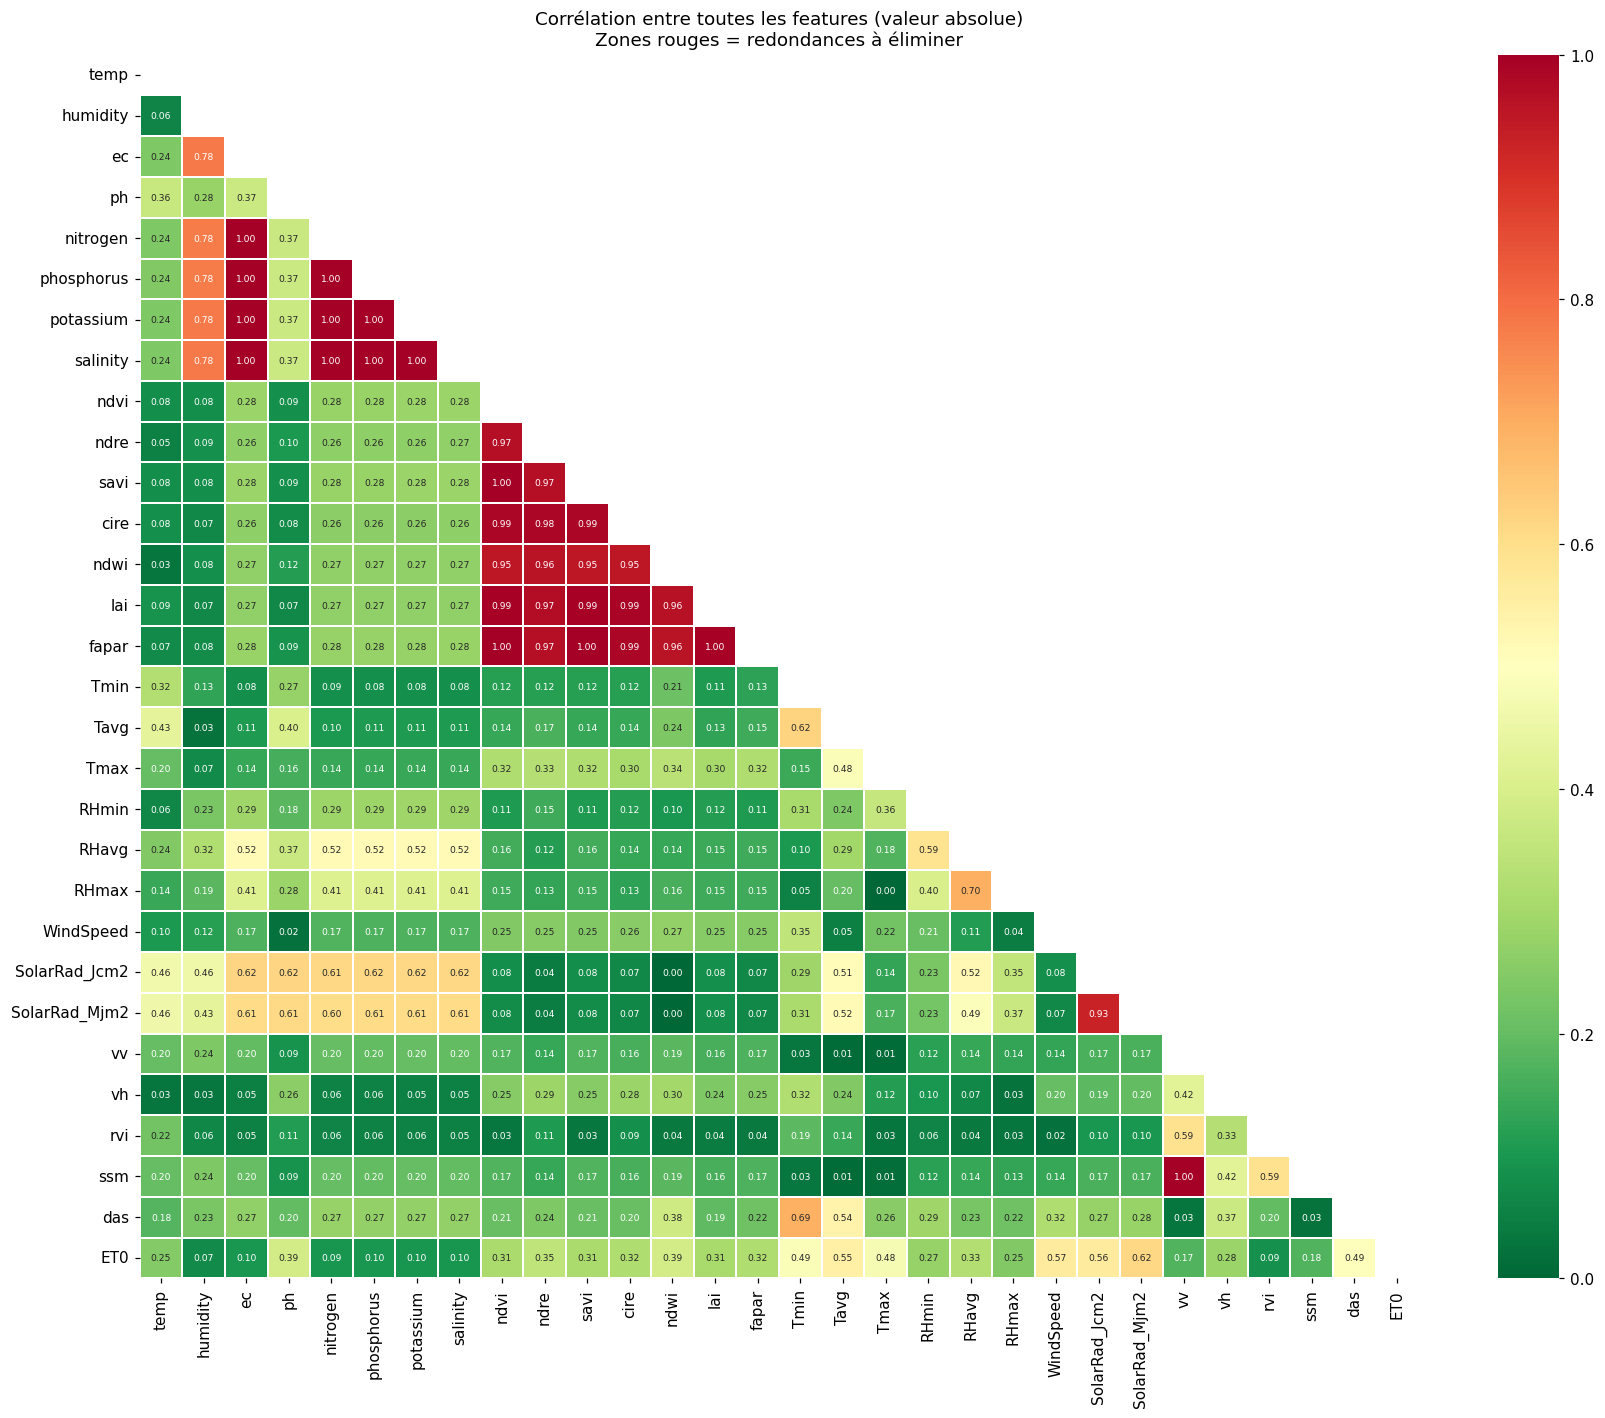

Figure sauvegardée : correlation_matrix_full.png


In [4]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── 1.1 Matrice de corrélation complète entre features ───────────────────────
all_features_raw = [c for c in df.columns
                    if c not in COLS_TO_EXCLUDE
                    and np.issubdtype(df[c].dtype, np.number)]

corr_matrix = df[all_features_raw].corr().abs()

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='RdYlGn_r', vmin=0, vmax=1,
            annot=True, fmt='.2f', linewidths=0.3, ax=ax,
            annot_kws={'size': 6})
ax.set_title("Corrélation entre toutes les features (valeur absolue)\n"
             "Zones rouges = redondances à éliminer", fontsize=12)
plt.tight_layout()
plt.savefig('correlation_matrix_full.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : correlation_matrix_full.png")

In [5]:
# ── 1.2 Groupes de variables redondantes identifiés ─────────────────────────
print("=" * 70)
print("ANALYSE DES REDONDANCES — Corrélation avec biomasse_cum")
print("=" * 70)

corr_with_target = (df[all_features_raw + ['biomasse_cum']]
                    .corr()['biomasse_cum']
                    .drop('biomasse_cum')
                    .abs()
                    .sort_values(ascending=False))
print(corr_with_target.round(3).to_string())

print("\n" + "=" * 70)
print("GROUPES DE VARIABLES HAUTEMENT CORRÉLÉES (r > 0.90)")
print("=" * 70)

groups_redondants = {
    "Indices spectraux optiques (r > 0.99 avec FAPAR)": {
        "conservé": "fapar",
        "supprimés": ["ndvi", "savi", "cire", "lai"],
        "raison": "FAPAR (fraction absorbée) — meilleure interprétation physique"
    },
    "Variables sol (r = 1.00 entre elles)": {
        "conservé": "ec",
        "supprimés": ["nitrogen", "phosphorus", "potassium", "salinity"],
        "raison": "EC représente la fertilité globale du sol"
    },
    "Température (r > 0.85)": {
        "conservé": "temp",
        "supprimés": ["Tmin", "Tavg", "Tmax"],
        "raison": "temp = mesure in-situ directe"
    },
    "Humidité relative (r > 0.85)": {
        "conservé": "RHavg",
        "supprimés": ["RHmin", "RHmax"],
        "raison": "RHavg = valeur centrale représentative"
    },
    "Rayonnement solaire (r = 0.93)": {
        "conservé": "SolarRad_Mjm2",
        "supprimés": ["SolarRad_Jcm2"],
        "raison": "Unité SI (MJ/m²)"
    },
    "Rétrodiffusion SAR (vv = ssm, r = 1.00)": {
        "conservé": "vv",
        "supprimés": ["ssm"],
        "raison": "vv identique à ssm dans ce dataset"
    },
}

for group, info in groups_redondants.items():
    print(f"\n  {group}")
    print(f"    ✅ Conservé  : {info['conservé']}")
    print(f"    ❌ Supprimés : {info['supprimés']}")
    print(f"    💡 Raison    : {info['raison']}")

print("\n  ndwi  : conservé (corrélation inverse avec végétation — stress hydrique)")
print("  ndre  : supprimé (r=0.97 avec fapar, fapar préféré)")
print("  ET0   : supprimé (variable dérivée, risque de leakage indirect)")
print("  ph    : supprimé (r=0.10 avec biomasse — contribution négligeable)")

ANALYSE DES REDONDANCES — Corrélation avec biomasse_cum
das              0.722
ndwi             0.457
potassium        0.441
salinity         0.441
nitrogen         0.440
ec               0.440
phosphorus       0.440
RHavg            0.433
Tmin             0.421
vh               0.405
fapar            0.379
savi             0.376
ndvi             0.376
lai              0.360
cire             0.358
RHmin            0.353
RHmax            0.347
ndre             0.335
WindSpeed        0.312
ssm              0.244
humidity         0.243
vv               0.242
ET0              0.230
temp             0.230
Tavg             0.199
Tmax             0.156
SolarRad_Jcm2    0.125
SolarRad_Mjm2    0.116
ph               0.101
rvi              0.049

GROUPES DE VARIABLES HAUTEMENT CORRÉLÉES (r > 0.90)

  Indices spectraux optiques (r > 0.99 avec FAPAR)
    ✅ Conservé  : fapar
    ❌ Supprimés : ['ndvi', 'savi', 'cire', 'lai']
    💡 Raison    : FAPAR (fraction absorbée) — meilleure interprétation phys

In [6]:
# ── 1.3 Définition du jeu de features sélectionnées ────────────────────────
SELECTED_FEATURES = [
    # Sol
    'ec',
    # Végétation optique
    'fapar', 'ndwi',
    # SAR
    'vv', 'vh', 'rvi',
    # Météo station
    'temp', 'humidity', 'RHavg', 'WindSpeed', 'SolarRad_Mjm2',
]

print(f"Features sélectionnées ({len(SELECTED_FEATURES)}) :")
for f in SELECTED_FEATURES:
    r = corr_with_target[f]
    print(f"  {f:<20} | r(biomasse) = {r:.3f}")

print(f"\nFeatures initiales : {len(all_features_raw)}")
print(f"Features retenues  : {len(SELECTED_FEATURES)}")
print(f"Réduction          : {len(all_features_raw) - len(SELECTED_FEATURES)} variables supprimées")

Features sélectionnées (11) :
  ec                   | r(biomasse) = 0.440
  fapar                | r(biomasse) = 0.379
  ndwi                 | r(biomasse) = 0.457
  vv                   | r(biomasse) = 0.242
  vh                   | r(biomasse) = 0.405
  rvi                  | r(biomasse) = 0.049
  temp                 | r(biomasse) = 0.230
  humidity             | r(biomasse) = 0.243
  RHavg                | r(biomasse) = 0.433
  WindSpeed            | r(biomasse) = 0.312
  SolarRad_Mjm2        | r(biomasse) = 0.116

Features initiales : 30
Features retenues  : 11
Réduction          : 19 variables supprimées


VIF des features sélectionnées :
      Feature        VIF
         ndwi 276.306055
           vh 146.032368
           vv 117.716630
        fapar  61.363113
         temp  44.843795
SolarRad_Mjm2  27.875367
          rvi  21.600954
     humidity  17.956084
    WindSpeed  14.951558
           ec  10.166910
        RHavg   9.702913

Note : RF et XGBoost sont robustes à la multicolinéarité résiduelle.
Le LSTM utilise un normalisation MinMax indépendante par feature.


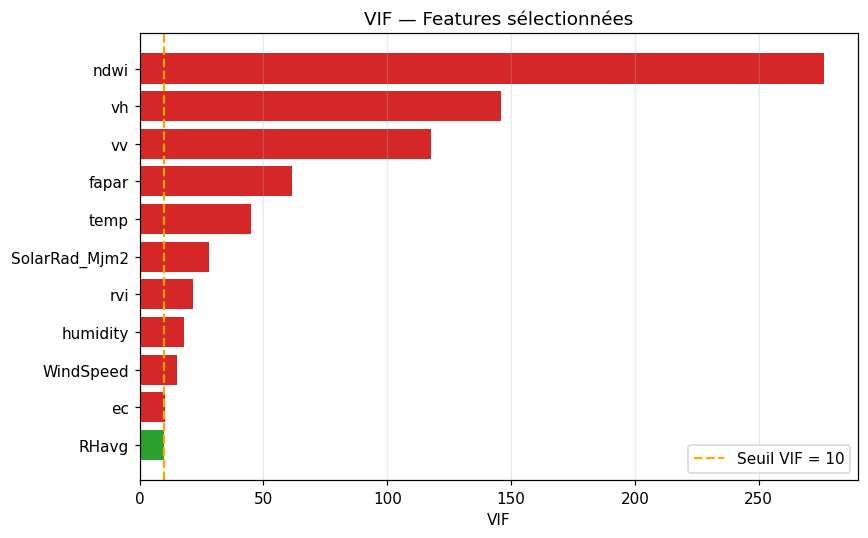

Figure sauvegardée : vif_selected_features.png


In [7]:
# ── 1.4 VIF sur les features sélectionnées ──────────────────────────────────
X_vif = (df[SELECTED_FEATURES]
         .astype(float)
         .replace([np.inf, -np.inf], np.nan)
         .dropna())

vif_df = pd.DataFrame({
    'Feature': X_vif.columns,
    'VIF':     [variance_inflation_factor(X_vif.values, i)
                for i in range(X_vif.shape[1])]
}).sort_values('VIF', ascending=False).reset_index(drop=True)

print("VIF des features sélectionnées :")
print(vif_df.to_string(index=False))
print("\nNote : RF et XGBoost sont robustes à la multicolinéarité résiduelle.")
print("Le LSTM utilise un normalisation MinMax indépendante par feature.")

fig, ax = plt.subplots(figsize=(8, 5))
colors_vif = ['#d62728' if v > 10 else '#2ca02c' for v in vif_df['VIF']]
ax.barh(vif_df['Feature'][::-1], vif_df['VIF'][::-1], color=colors_vif[::-1])
ax.axvline(10, color='orange', linestyle='--', label='Seuil VIF = 10')
ax.set_xlabel("VIF"); ax.set_title("VIF — Features sélectionnées")
ax.legend(); ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('vif_selected_features.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : vif_selected_features.png")

In [8]:
# ── 1.5 Mise à jour de la liste d'exclusion pour les modèles ────────────────
# Les modèles n'utiliseront que SELECTED_FEATURES (défini ci-dessus).
# COLS_TO_EXCLUDE sert uniquement à filtrer automatiquement les colonnes non-numériques.
# On redéfinit une fonction utilitaire pour obtenir les features d'un sous-ensemble.

def get_features(subset_df):
    """Retourne SELECTED_FEATURES présentes dans le DataFrame et sans NaN."""
    return [f for f in SELECTED_FEATURES
            if f in subset_df.columns
            and np.issubdtype(subset_df[f].dtype, np.number)]

print("✅ Fonction get_features() définie — utilise SELECTED_FEATURES.")
print("Features utilisées par les modèles :", SELECTED_FEATURES)

✅ Fonction get_features() définie — utilise SELECTED_FEATURES.
Features utilisées par les modèles : ['ec', 'fapar', 'ndwi', 'vv', 'vh', 'rvi', 'temp', 'humidity', 'RHavg', 'WindSpeed', 'SolarRad_Mjm2']


---
## Partie 2 — Vérification du Data Leakage

### 2.1 Corrélation temporelle des features (leakage indirect)


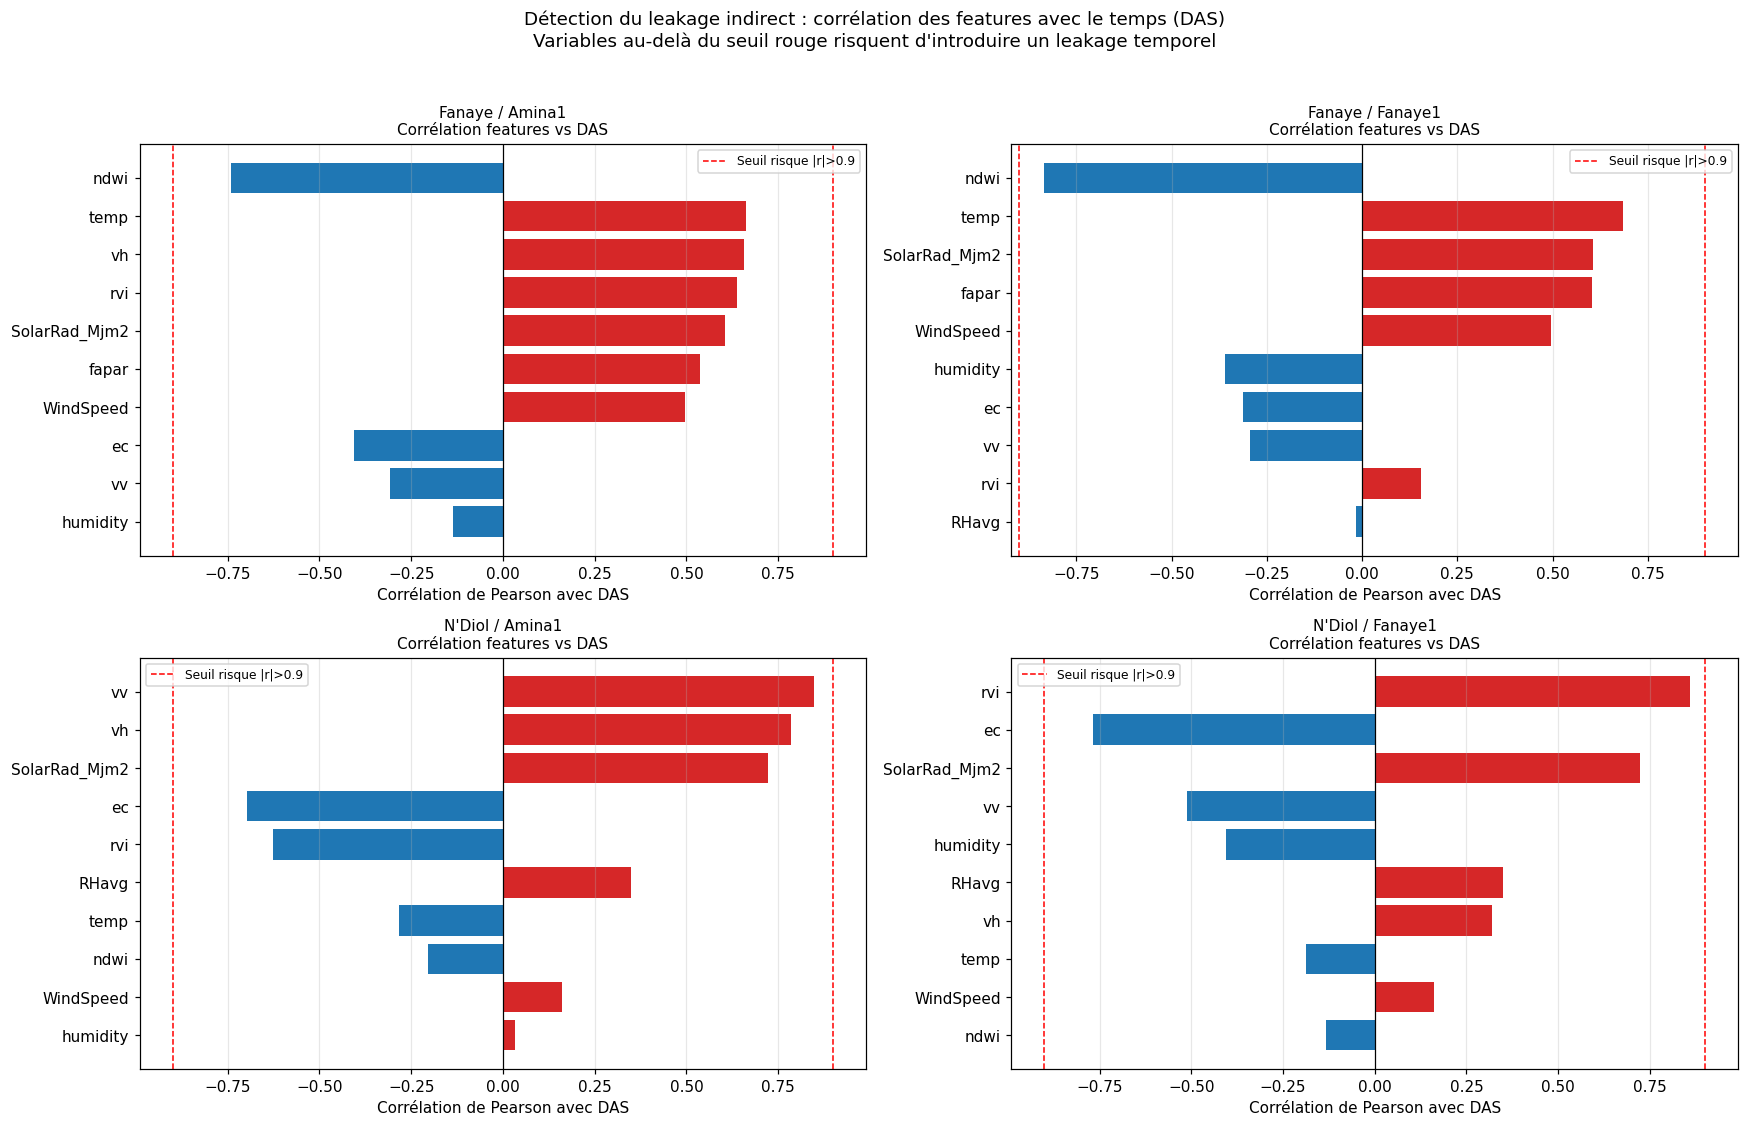

Figure sauvegardée : correlation_features_vs_das.png


In [9]:
# ── 2.1 Corrélation features × DAS ──────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()

for ax, (group_name, site, variete) in zip(axes, GROUPS):
    subset = df[(df['site'] == site) & (df['variete'] == variete)].copy().sort_values('date')
    feats  = get_features(subset)

    corr_das = subset[feats + ['das']].corr()['das'].drop('das')
    if isinstance(corr_das, pd.DataFrame):
        corr_das = corr_das.iloc[:, 0]
    corr_das = corr_das.sort_values(key=abs, ascending=False)

    top    = corr_das.head(10)
    colors = ['#d62728' if v > 0 else '#1f77b4' for v in top.values]
    ax.barh(top.index[::-1], top.values[::-1], color=colors[::-1])
    ax.axvline(0,   color='black', linewidth=0.8)
    ax.axvline(0.9, color='red', linestyle='--', linewidth=1, label='Seuil risque |r|>0.9')
    ax.axvline(-0.9,color='red', linestyle='--', linewidth=1)
    ax.set_title(f"{site} / {variete}\nCorrélation features vs DAS", fontsize=10)
    ax.set_xlabel("Corrélation de Pearson avec DAS")
    ax.legend(fontsize=8); ax.grid(alpha=0.3, axis='x')

plt.suptitle("Détection du leakage indirect : corrélation des features avec le temps (DAS)\n"
             "Variables au-delà du seuil rouge risquent d'introduire un leakage temporel",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('correlation_features_vs_das.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : correlation_features_vs_das.png")

### 2.2 Démonstration quantitative : split aléatoire vs temporel

In [19]:
from sklearn.model_selection import train_test_split
import xgboost as xgb
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

SEED = 42

def evaluate_split_xgb(X, y, train_idx, test_idx, label):
    Xtr, Xte = X.iloc[train_idx], X.iloc[test_idx]
    ytr, yte = y.iloc[train_idx], y.iloc[test_idx]
    m = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1,
                          max_depth=5, random_state=SEED, verbosity=0)
    m.fit(Xtr, ytr)
    pred = m.predict(Xte)
    r2   = r2_score(yte, pred)
    rmse = np.sqrt(mean_squared_error(yte, pred))
    print(f"  {label:<50s} | R²={r2:8.4f} | RMSE={rmse:8.4f} | n_test={len(test_idx)}")
    return r2, rmse

print("=" * 80)
print("DÉMONSTRATION DU DATA LEAKAGE — Fanaye / Amina1")
print("=" * 80)

demo = (df[(df['site'] == 'Fanaye') & (df['variete'] == 'Amina1')]
        .copy().sort_values('date').reset_index(drop=True))
feats_demo = get_features(demo)
X_demo, y_demo = demo[feats_demo], demo['biomasse_cum']
n   = len(demo)
idx = np.arange(n)

print("\n[SPLIT ALÉATOIRE — biaisé, avec leakage]")
r2_list, rmse_list = [], []
for seed in [42, 123, 7, 99, 55]:
    tr, te = train_test_split(idx, test_size=0.2, random_state=seed)
    r2, rmse = evaluate_split_xgb(X_demo, y_demo, tr, te, f"Random split (seed={seed})")
    r2_list.append(r2); rmse_list.append(rmse)
print(f"  → Moy R²={np.mean(r2_list):.4f} ± {np.std(r2_list):.4f} | RMSE={np.mean(rmse_list):.4f}")

print("\n[SPLIT TEMPOREL STRICT — extrapolation pure]")
sp = int(n * 0.8)
evaluate_split_xgb(X_demo, y_demo, np.arange(sp), np.arange(sp, n),
                   "Temporel strict (train=début, test=fin)")

print("\n\033[1m[SPLIT SYSTÉMATIQUE — retenu pour ce notebook]\033[0m")
te_sys = np.arange(4, n, 5)
tr_sys = np.array([i for i in range(n) if i not in te_sys])
evaluate_split_xgb(X_demo, y_demo, tr_sys, te_sys,
                   "\033[1mSystématique (1 pt / 5, réparti sur le cycle)\033[0m")

print("\n⚠  Le split aléatoire surestime R² car des points temporellement proches")
print("   du test se retrouvent dans le train → fuite d'information.")
print("   Ce notebook utilise exclusivement le split systématique.")

DÉMONSTRATION DU DATA LEAKAGE — Fanaye / Amina1

[SPLIT ALÉATOIRE — biaisé, avec leakage]
  Random split (seed=42)                             | R²=  0.9952 | RMSE=  0.7357 | n_test=21
  Random split (seed=123)                            | R²=  0.9943 | RMSE=  0.7398 | n_test=21
  Random split (seed=7)                              | R²=  0.9515 | RMSE=  2.4079 | n_test=21
  Random split (seed=99)                             | R²=  0.9986 | RMSE=  0.4352 | n_test=21
  Random split (seed=55)                             | R²=  0.9936 | RMSE=  0.8557 | n_test=21
  → Moy R²=0.9867 ± 0.0177 | RMSE=1.0349

[SPLIT TEMPOREL STRICT — extrapolation pure]
  Temporel strict (train=début, test=fin)            | R²=-596.3126 | RMSE= 23.8916 | n_test=21

[SPLIT SYSTÉMATIQUE — retenu pour ce notebook]
  Systématique (1 pt / 5, réparti sur le cycle) | R²=  0.9988 | RMSE=  0.3569 | n_test=20

⚠  Le split aléatoire surestime R² car des points temporellement proches
   du test se retrouvent dans le train →

### 2.3 Fonction de split temporel systématique

In [11]:
def systematic_temporal_split(n, test_every=5, offset=4):
    """1 point sur test_every mis en test, réparti sur tout le cycle phénologique."""
    test_idx  = np.arange(offset, n, test_every)
    train_idx = np.array([i for i in range(n) if i not in test_idx])
    return train_idx, test_idx

print("✅ Fonction 'systematic_temporal_split' définie.")

✅ Fonction 'systematic_temporal_split' définie.


---
## Partie 3 — Entraînement et évaluation des modèles

### 3.1 Fonction générique — Random Forest et XGBoost


In [31]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def train_tree_model(df, site, variete, model_type,
                     test_every=5, offset=4, random_state=SEED):
    """Entraîne RF ou XGBoost avec split systématique sur les features sélectionnées."""
    subset = (df[(df['site'] == site) & (df['variete'] == variete)]
              .copy().sort_values('date').reset_index(drop=True))

    features = get_features(subset)
    X = subset[features]
    y = subset['biomasse_cum']

    valid = y.notna()
    X, y, subset = X[valid].reset_index(drop=True), y[valid].reset_index(drop=True), subset[valid].reset_index(drop=True)
    n = len(subset)

    train_idx, test_idx = systematic_temporal_split(n, test_every, offset)
    X_train, X_test     = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test     = y.iloc[train_idx], y.iloc[test_idx]

    if model_type == 'RandomForest':
        model = RandomForestRegressor(n_estimators=200, max_depth=8,
                                      min_samples_leaf=2, random_state=random_state,
                                      n_jobs=-1, oob_score=True)
        model.fit(X_train, y_train)
    elif model_type == 'XGBoost':
        model = xgb.XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=5,
                                  random_state=random_state, verbosity=0,
                                  eval_metric='rmse')
        model.fit(X_train, y_train,
                  eval_set=[(X_train, y_train), (X_test, y_test)],
                  verbose=False)
    else:
        raise ValueError("model_type doit être 'RandomForest' ou 'XGBoost'")

    y_pred       = model.predict(X_test)
    y_pred_train = model.predict(X_train)

    result = {
        'Modèle': model_type, 'Groupe': f"{site} / {variete}",
        'Site': site, 'Variété': variete,
        'Observations': n, 'N_train': len(train_idx), 'N_test': len(test_idx),
        'R²':      r2_score(y_test, y_pred),
        'RMSE':    np.sqrt(mean_squared_error(y_test, y_pred)),
        'MAE':     mean_absolute_error(y_test, y_pred),
        'R²_train':   r2_score(y_train, y_pred_train),
        'RMSE_train': np.sqrt(mean_squared_error(y_train, y_pred_train)),
    }

    importances = (pd.DataFrame({'Feature': features,
                                  'Importance': model.feature_importances_})
                   .sort_values('Importance', ascending=False)
                   .reset_index(drop=True))

    preds_df = subset[['date', 'das']].copy()
    preds_df['biomasse_obs']      = y.values
    preds_df['split']             = 'train'
    preds_df.loc[test_idx, 'split'] = 'test'
    preds_df['biomasse_pred']     = np.nan
    preds_df.loc[test_idx, 'biomasse_pred'] = y_pred
    preds_df['biomasse_pred_full'] = model.predict(X)

    return model, result, importances, preds_df, (X_train, X_test, y_train, y_test)

In [30]:
from sklearn.inspection import permutation_importance
import pandas as pd

# The original error occurred because `model` was an LSTM model,
# which does not have a `.score()` method expected by default by permutation_importance.
# Also, X_test and y_test were likely not in the correct format for an LSTM.

# To fix this and provide a meaningful permutation importance for a tree-based model,
# we retrieve a specific XGBoost model and its corresponding test data.
# For example, let's use the XGBoost model for the 'Fanaye_Amina1' group.

# Assuming xgb_models and xgb_data are available from previous training cells
model_to_analyze = xgb_models['Fanaye_Amina1']
X_test_data = xgb_data['Fanaye_Amina1'][1] # X_test from the tuple
y_test_data = xgb_data['Fanaye_Amina1'][3] # y_test from the tuple

perm = permutation_importance(
    model_to_analyze,
    X_test_data,
    y_test_data,
    n_repeats=30,
    random_state=42
)

perm_imp = pd.DataFrame({
    "Feature": X_test_data.columns,
    "Importance": perm.importances_mean
}).sort_values(
    "Importance",
    ascending=False
)

print("Permutation Importance for XGBoost (Fanaye / Amina1):")
print(perm_imp)

Permutation Importance for XGBoost (Fanaye / Amina1):
          Feature  Importance
2            ndwi    1.477840
1           fapar    0.159134
3              vv    0.024733
4              vh    0.018322
5             rvi    0.001652
10  SolarRad_Mjm2    0.000480
6            temp    0.000089
7        humidity    0.000063
9       WindSpeed    0.000046
0              ec   -0.000011
8           RHavg   -0.000124


### 3.2 Entraînement Random Forest

In [32]:
from sklearn.ensemble import RandomForestRegressor

rf_models = {}
rf_data   = {}

for group_name, site, variete in GROUPS:
    model, result, importances, preds_df, split_data = train_tree_model(
        df, site, variete, 'RandomForest')
    rf_models[group_name] = model
    rf_data[group_name]   = split_data
    all_results.append(result)
    feature_importance_store[('RandomForest', group_name)] = importances
    predictions_store[('RandomForest', group_name)]        = preds_df
    print(f"[RF]  {site} / {variete:<10} | "
          f"R²={result['R²']:.4f} | RMSE={result['RMSE']:.4f} | MAE={result['MAE']:.4f} | "
          f"R²_train={result['R²_train']:.4f}")

[RF]  Fanaye / Amina1     | R²=0.9914 | RMSE=0.9567 | MAE=0.5598 | R²_train=0.9944
[RF]  Fanaye / Fanaye1    | R²=0.9851 | RMSE=0.9738 | MAE=0.5720 | R²_train=0.9937
[RF]  N'Diol / Amina1     | R²=0.9951 | RMSE=2.1357 | MAE=0.9505 | R²_train=0.9990
[RF]  N'Diol / Fanaye1    | R²=0.9463 | RMSE=3.1702 | MAE=1.8815 | R²_train=0.9917


### 3.3 Entraînement XGBoost

In [33]:
xgb_models = {}
xgb_data   = {}

for group_name, site, variete in GROUPS:
    model, result, importances, preds_df, split_data = train_tree_model(
        df, site, variete, 'XGBoost')
    xgb_models[group_name] = model
    xgb_data[group_name]   = split_data
    all_results.append(result)
    feature_importance_store[('XGBoost', group_name)] = importances
    predictions_store[('XGBoost', group_name)]        = preds_df
    print(f"[XGB] {site} / {variete:<10} | "
          f"R²={result['R²']:.4f} | RMSE={result['RMSE']:.4f} | MAE={result['MAE']:.4f} | "
          f"R²_train={result['R²_train']:.4f}")

[XGB] Fanaye / Amina1     | R²=0.9988 | RMSE=0.3565 | MAE=0.2595 | R²_train=1.0000
[XGB] Fanaye / Fanaye1    | R²=0.9979 | RMSE=0.3652 | MAE=0.2886 | R²_train=1.0000
[XGB] N'Diol / Amina1     | R²=0.9969 | RMSE=1.7051 | MAE=0.8886 | R²_train=1.0000
[XGB] N'Diol / Fanaye1    | R²=0.8675 | RMSE=4.9779 | MAE=1.6556 | R²_train=1.0000


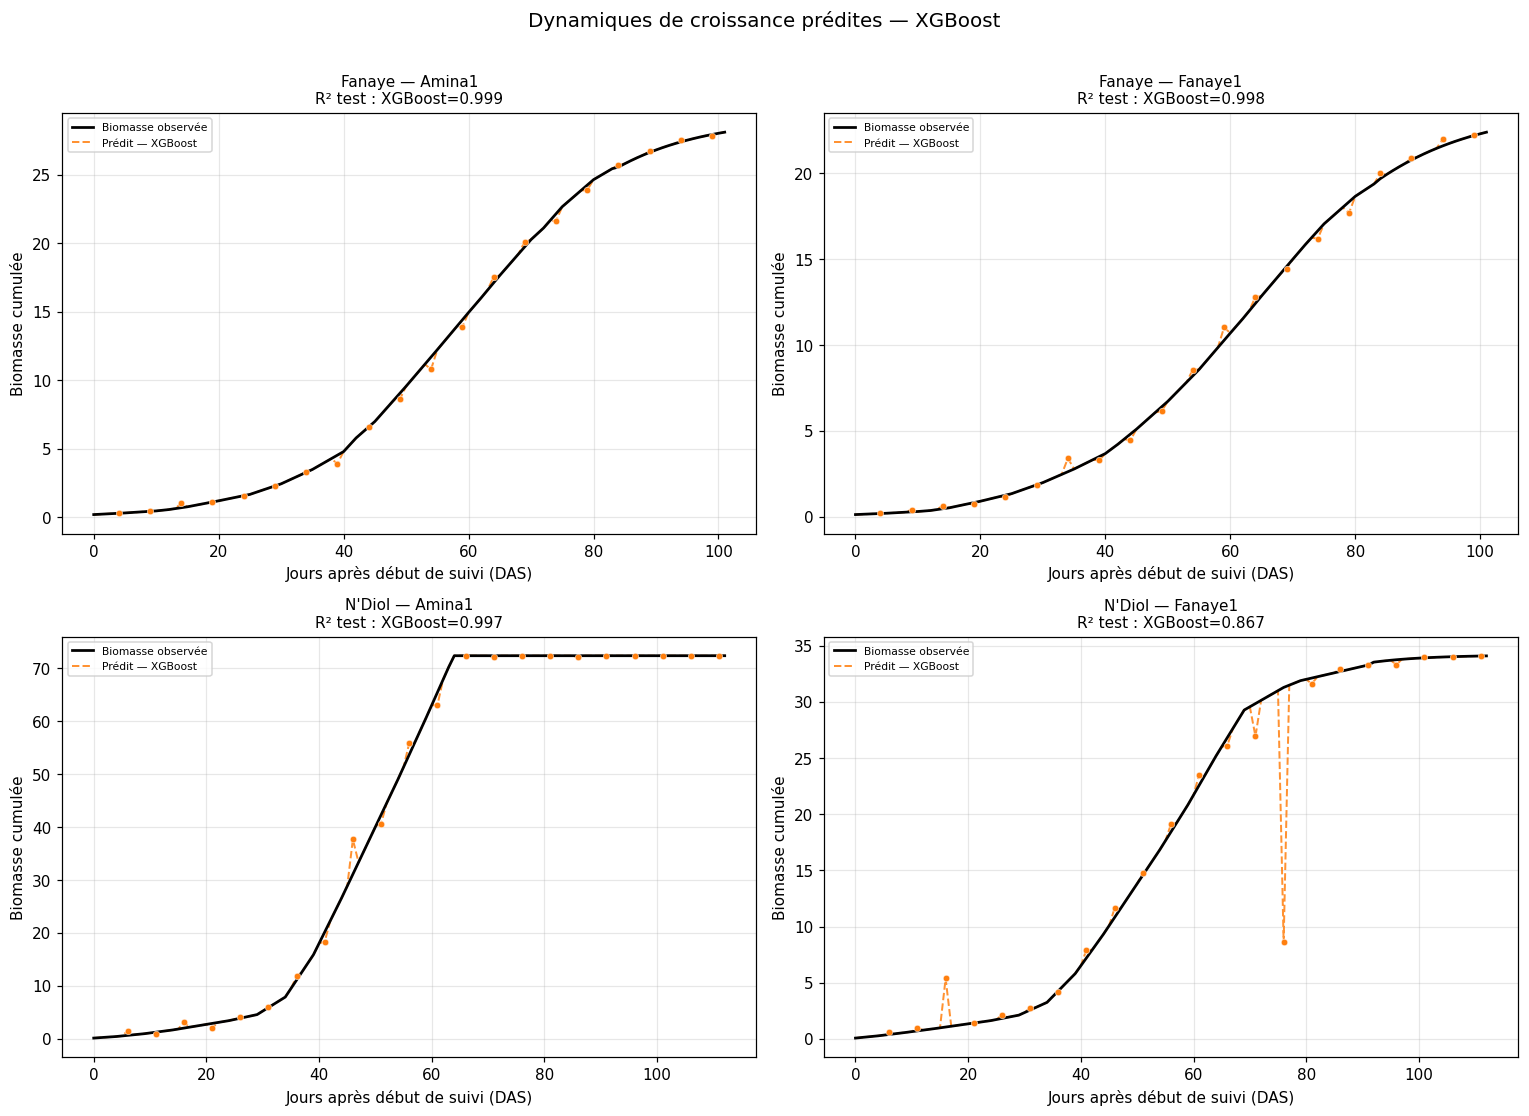

Figure sauvegardée : growth_dynamics_xgboost.png


In [34]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for ax, (group_name, site, variete) in zip(axes, GROUPS):
    # Get observed biomass from any model's prediction store (they all have the same observed data)
    obs_ref = predictions_store[('RandomForest', group_name)] # Using RF for observed data reference
    ax.plot(obs_ref['das'], obs_ref['biomasse_obs'],
            color='black', linewidth=1.8, label='Biomasse observée', zorder=3)

    # Get XGBoost predictions
    pdf_xgb = predictions_store[('XGBoost', group_name)]
    ax.plot(pdf_xgb['das'], pdf_xgb['biomasse_pred_full'],
            color=model_colors['XGBoost'], linestyle='--',
            linewidth=1.3, label=f'Prédit — XGBoost', alpha=0.85)

    # Highlight test points for XGBoost
    test_mask_xgb = pdf_xgb['split'] == 'test'
    ax.scatter(pdf_xgb.loc[test_mask_xgb, 'das'], pdf_xgb.loc[test_mask_xgb, 'biomasse_pred'],
               color=model_colors['XGBoost'], s=18, zorder=4,
               edgecolor='white', linewidth=0.3)

    # Retrieve R² for XGBoost
    r2_xgb = results_df[(results_df.Groupe == f"{site} / {variete}") &
                        (results_df.Modèle == 'XGBoost')]['R²'].values[0]

    ax.set_title(f"{site} — {variete}\nR² test : XGBoost={r2_xgb:.3f}",
                 fontsize=10)
    ax.set_xlabel("Jours après début de suivi (DAS)")
    ax.set_ylabel("Biomasse cumulée")
    ax.legend(fontsize=7, loc='upper left'); ax.grid(alpha=0.3)

plt.suptitle("Dynamiques de croissance prédites — XGBoost",
             y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig('growth_dynamics_xgboost.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : growth_dynamics_xgboost.png")

### 3.4 Entraînement LSTM

In [15]:
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

WINDOW = 5

def make_sequences(X_scaled, y, window):
    Xs, ys = [], []
    for i in range(len(X_scaled) - window):
        Xs.append(X_scaled[i:i + window])
        ys.append(y[i + window])
    return np.array(Xs), np.array(ys)

def build_lstm_model(n_timesteps, n_features):
    model = Sequential([
        LSTM(32, activation='tanh', input_shape=(n_timesteps, n_features)),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

def train_lstm_model(df, site, variete, window=WINDOW,
                     test_every=5, offset=4, epochs=150, random_state=SEED):
    subset = (df[(df['site'] == site) & (df['variete'] == variete)]
              .copy().sort_values('date').reset_index(drop=True))

    features   = get_features(subset)
    X_raw      = subset[features].values
    y_raw      = subset['biomasse_cum'].values
    dates_raw  = subset['date'].values
    das_raw    = subset['das'].values

    scaler_X = MinMaxScaler()
    X_scaled = scaler_X.fit_transform(X_raw)
    scaler_y = MinMaxScaler()
    y_scaled = scaler_y.fit_transform(y_raw.reshape(-1, 1)).flatten()

    X_seq, y_seq     = make_sequences(X_scaled, y_scaled, window)
    dates_seq, das_seq = dates_raw[window:], das_raw[window:]
    n_seq            = len(y_seq)

    train_idx, test_idx = systematic_temporal_split(n_seq, test_every, offset)
    X_train, X_test     = X_seq[train_idx], X_seq[test_idx]
    y_train, y_test     = y_seq[train_idx], y_seq[test_idx]

    tf.random.set_seed(random_state)
    model      = build_lstm_model(n_timesteps=window, n_features=X_seq.shape[2])
    early_stop = EarlyStopping(monitor='val_loss', patience=15,
                               restore_best_weights=True)
    history = model.fit(X_train, y_train, epochs=epochs, batch_size=8,
                        verbose=0, callbacks=[early_stop],
                        validation_data=(X_test, y_test))

    def inv(arr):
        return scaler_y.inverse_transform(arr.reshape(-1, 1)).flatten()

    y_pred_real       = inv(model.predict(X_test,  verbose=0).flatten())
    y_full_real       = inv(model.predict(X_seq,   verbose=0).flatten())
    y_train_pred_real = inv(model.predict(X_train, verbose=0).flatten())
    y_test_real       = inv(y_test)
    y_train_real      = inv(y_train)
    y_seq_real        = inv(y_seq)

    result = {
        'Modèle': 'LSTM', 'Groupe': f"{site} / {variete}",
        'Site': site, 'Variété': variete,
        'Observations': n_seq, 'N_train': len(train_idx), 'N_test': len(test_idx),
        'R²':      r2_score(y_test_real, y_pred_real),
        'RMSE':    np.sqrt(mean_squared_error(y_test_real, y_pred_real)),
        'MAE':     mean_absolute_error(y_test_real, y_pred_real),
        'R²_train':   r2_score(y_train_real, y_train_pred_real),
        'RMSE_train': np.sqrt(mean_squared_error(y_train_real, y_train_pred_real)),
    }

    # LSTM models do not have a .feature_importances_ attribute like tree-based models.
    # Feature importances for LSTMs are typically derived through more complex methods
    # (e.g., permutation importance, SHAP values for specific interpretations)
    # and are not directly available from the model object.
    # Therefore, we will not include feature importances for LSTMs in this function's return.
    importances = pd.DataFrame({'Feature': [], 'Importance': []}) # Return empty DataFrame or handle as needed

    preds_df = pd.DataFrame({'date': dates_seq, 'das': das_seq, 'biomasse_obs': y_seq_real})
    preds_df['split'] = 'train'
    preds_df.loc[test_idx, 'split'] = 'test'
    preds_df['biomasse_pred'] = np.nan
    preds_df.loc[test_idx, 'biomasse_pred'] = y_pred_real
    preds_df['biomasse_pred_full'] = y_full_real

    return model, result, preds_df, history, (scaler_X, scaler_y, features)

print("✅ Fonctions LSTM définies.")

✅ Fonctions LSTM définies.


In [16]:
from sklearn.preprocessing import MinMaxScaler

lstm_models   = {}
lstm_scalers  = {}
lstm_histories = {}

for group_name, site, variete in GROUPS:
    model, result, preds_df, history, scalers = train_lstm_model(df, site, variete)
    lstm_models[group_name]    = model
    lstm_scalers[group_name]   = scalers
    lstm_histories[group_name] = history
    all_results.append(result)
    predictions_store[('LSTM', group_name)] = preds_df
    print(f"[LSTM] {site} / {variete:<10} | "
          f"R²={result['R²']:.4f} | RMSE={result['RMSE']:.4f} | MAE={result['MAE']:.4f} | "
          f"R²_train={result['R²_train']:.4f} | "
          f"Époques={len(history.history['loss'])}")

[LSTM] Fanaye / Amina1     | R²=0.9963 | RMSE=0.6228 | MAE=0.4277 | R²_train=0.9977 | Époques=150
[LSTM] Fanaye / Fanaye1    | R²=0.9893 | RMSE=0.8159 | MAE=0.6376 | R²_train=0.9936 | Époques=96


[LSTM] N'Diol / Amina1     | R²=0.9940 | RMSE=2.3117 | MAE=1.6778 | R²_train=0.9940 | Époques=99


[LSTM] N'Diol / Fanaye1    | R²=0.9939 | RMSE=1.0449 | MAE=0.7937 | R²_train=0.9897 | Époques=108


---
## Partie 4 — Diagnostic du surapprentissage

### 4.1 Tableau comparatif Train vs Test (tous modèles)


In [17]:
results_df = pd.DataFrame(all_results)

print("=" * 80)
print("PERFORMANCES TRAIN vs TEST — TOUS MODÈLES ET GROUPES")
print("=" * 80)
display(results_df[['Modèle', 'Groupe', 'N_train', 'N_test',
                     'R²_train', 'R²', 'RMSE_train', 'RMSE', 'MAE']].round(4))

# Surapprentissage = écart R² train-test > 0.15
results_df['Δ R²'] = results_df['R²_train'] - results_df['R²']
surfit = results_df[results_df['Δ R²'] > 0.15]
if len(surfit):
    print("\n⚠ Groupes potentiellement sur-entraînés (ΔR² > 0.15) :")
    print(surfit[['Modèle', 'Groupe', 'R²_train', 'R²', 'Δ R²']].round(4).to_string(index=False))
else:
    print("\n✅ Pas de surapprentissage détecté (ΔR² ≤ 0.15 pour tous les groupes).")

PERFORMANCES TRAIN vs TEST — TOUS MODÈLES ET GROUPES


,Modèle,Groupe,N_train,N_test,R²_train,R²,RMSE_train,RMSE,MAE
0,RandomForest,Fanaye / Amina1,82,20,0.9944,0.9914,0.7772,0.9567,0.5598
1,RandomForest,Fanaye / Fanaye1,82,20,0.9937,0.9851,0.6348,0.9738,0.5720
2,RandomForest,N'Diol / Amina1,89,22,0.9990,0.9951,0.9972,2.1357,0.9505
3,RandomForest,N'Diol / Fanaye1,89,22,0.9917,0.9463,1.2561,3.1702,1.8815
4,XGBoost,Fanaye / Amina1,82,20,1.0000,0.9988,0.0009,0.3565,0.2595
5,XGBoost,Fanaye / Fanaye1,82,20,1.0000,0.9979,0.0009,0.3652,0.2886
6,XGBoost,N'Diol / Amina1,89,22,1.0000,0.9969,0.0009,1.7051,0.8886
7,XGBoost,N'Diol / Fanaye1,89,22,1.0000,0.8675,0.0011,4.9779,1.6556
8,LSTM,Fanaye / Amina1,78,19,0.9977,0.9963,0.4960,0.6228,0.4277
9,LSTM,Fanaye / Fanaye1,78,19,0.9936,0.9893,0.6368,0.8159,0.6376



✅ Pas de surapprentissage détecté (ΔR² ≤ 0.15 pour tous les groupes).


### 4.2 Courbes Loss Train/Validation — LSTM

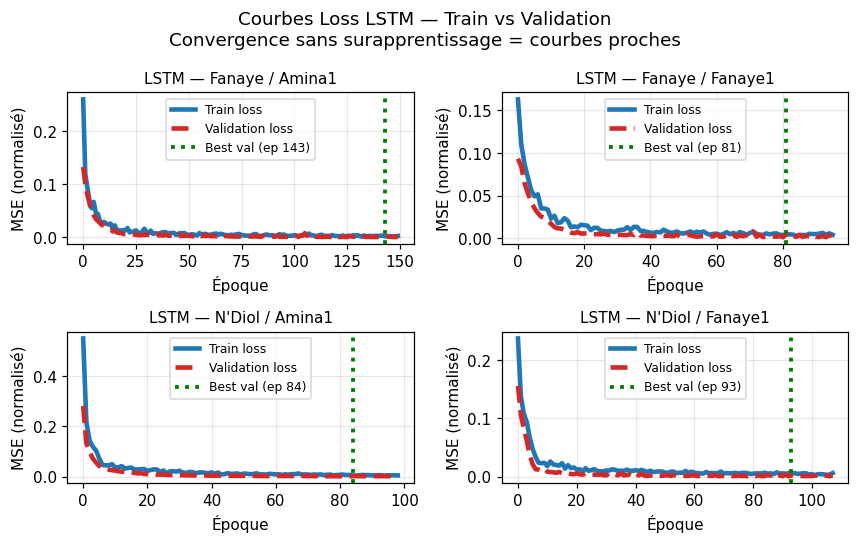

Figure sauvegardée : lstm_loss_train_val.png


In [24]:
fig, axes = plt.subplots(2, 2, figsize=(8, 5))
axes = axes.ravel()

for ax, (group_name, site, variete) in zip(axes, GROUPS):
    hist = lstm_histories[group_name].history
    ax.plot(hist['loss'],     label='Train loss',      color='#1f77b4', linewidth=3)
    ax.plot(hist['val_loss'], label='Validation loss', color='#d62728',
            linestyle='--', linewidth=3)
    ax.set_title(f"LSTM — {site} / {variete}", fontsize=10)
    ax.set_xlabel("Époque"); ax.set_ylabel("MSE (normalisé)")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
    # Annoter les époques
    best_ep = np.argmin(hist['val_loss']) + 1
    ax.axvline(best_ep, color='green', linestyle=':', linewidth=2.5,
               label=f"Best val (ep {best_ep})")
    ax.legend(fontsize=8)

plt.suptitle("Courbes Loss LSTM — Train vs Validation\n"
             "Convergence sans surapprentissage = courbes proches", fontsize=12)
plt.tight_layout()
plt.savefig('lstm_loss_train_val.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : lstm_loss_train_val.png")
plt.close(fig) # Close the figure to avoid displaying it in the notebook output

### 4.3 Courbes d'apprentissage — Random Forest (OOB) et XGBoost

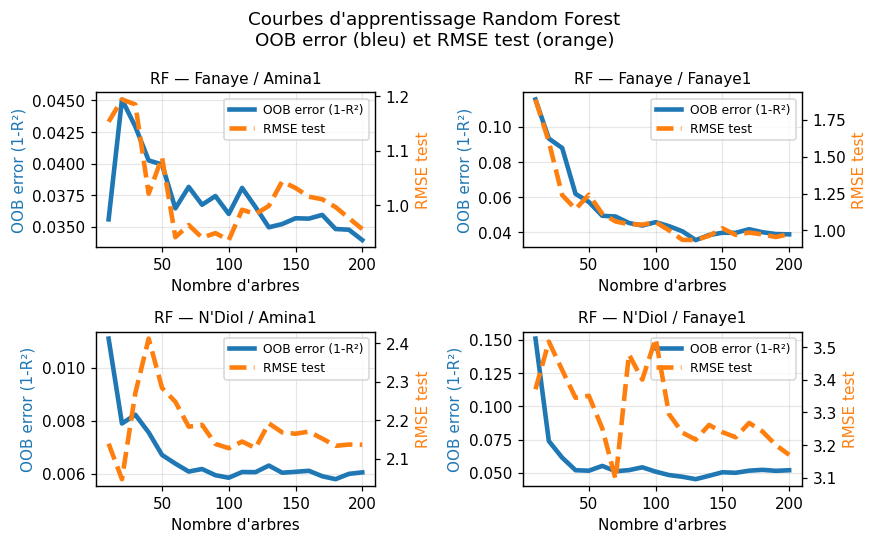

In [26]:
from sklearn.ensemble import RandomForestRegressor as RFR

fig, axes = plt.subplots(2, 2, figsize=(8, 5))
axes = axes.ravel()

for ax, (group_name, site, variete) in zip(axes, GROUPS):
    X_train, X_test, y_train, y_test = rf_data[group_name]

    # RF : erreur OOB en fonction du nombre d'arbres
    oob_errors, test_errors = [], []
    n_trees_range = range(10, 201, 10)
    for n in n_trees_range:
        rf_tmp = RFR(n_estimators=n, max_depth=8, min_samples_leaf=2,
                     random_state=SEED, n_jobs=-1, oob_score=True)
        rf_tmp.fit(X_train, y_train)
        oob_errors.append(1 - rf_tmp.oob_score_)
        y_p = rf_tmp.predict(X_test)
        test_errors.append(np.sqrt(mean_squared_error(y_test, y_p)))

    ax2 = ax.twinx()
    ax.plot(n_trees_range,  oob_errors,  color='#1f77b4', label='OOB error (1-R²)', linewidth=3)
    ax2.plot(n_trees_range, test_errors, color='#ff7f0e', linestyle='--',
             label='RMSE test', linewidth=3)
    ax.set_xlabel("Nombre d'arbres")
    ax.set_ylabel("OOB error (1-R²)", color='#1f77b4')
    ax2.set_ylabel("RMSE test", color='#ff7f0e')
    ax.set_title(f"RF — {site} / {variete}", fontsize=10)
    lines1, lab1 = ax.get_legend_handles_labels()
    lines2, lab2 = ax2.get_legend_handles_labels()
    ax.legend(lines1+lines2, lab1+lab2, fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle("Courbes d'apprentissage Random Forest\n"
             "OOB error (bleu) et RMSE test (orange)", fontsize=12)
plt.tight_layout()
plt.savefig('rf_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.ravel()

for ax, (group_name, site, variete) in zip(axes, GROUPS):
    X_train, X_test, y_train, y_test = xgb_data[group_name]

    xgb_tmp = xgb.XGBRegressor(n_estimators=300, learning_rate=0.1,
                                max_depth=5, random_state=SEED, verbosity=0,
                                eval_metric='rmse')
    xgb_tmp.fit(X_train, y_train,
                eval_set=[(X_train, y_train), (X_test, y_test)],
                verbose=False)

    evals = xgb_tmp.evals_result()
    ax.plot(evals['validation_0']['rmse'], label='Train RMSE', color='#1f77b4')
    ax.plot(evals['validation_1']['rmse'], label='Test RMSE',  color='#d62728',
            linestyle='--')
    ax.set_title(f"XGBoost — {site} / {variete}", fontsize=10)
    ax.set_xlabel("Iteration (arbres)"); ax.set_ylabel("RMSE")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle("Courbes d'apprentissage XGBoost\n"
             "Train (bleu) vs Test (rouge) — convergence sans divergence = pas de surfit",
             fontsize=12)
plt.tight_layout()
plt.savefig('xgb_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : xgb_learning_curves.png")

---
## Partie 5 — Graphiques Observé vs Prédit et résidus

### 5.1 Observé vs Prédit — tous modèles


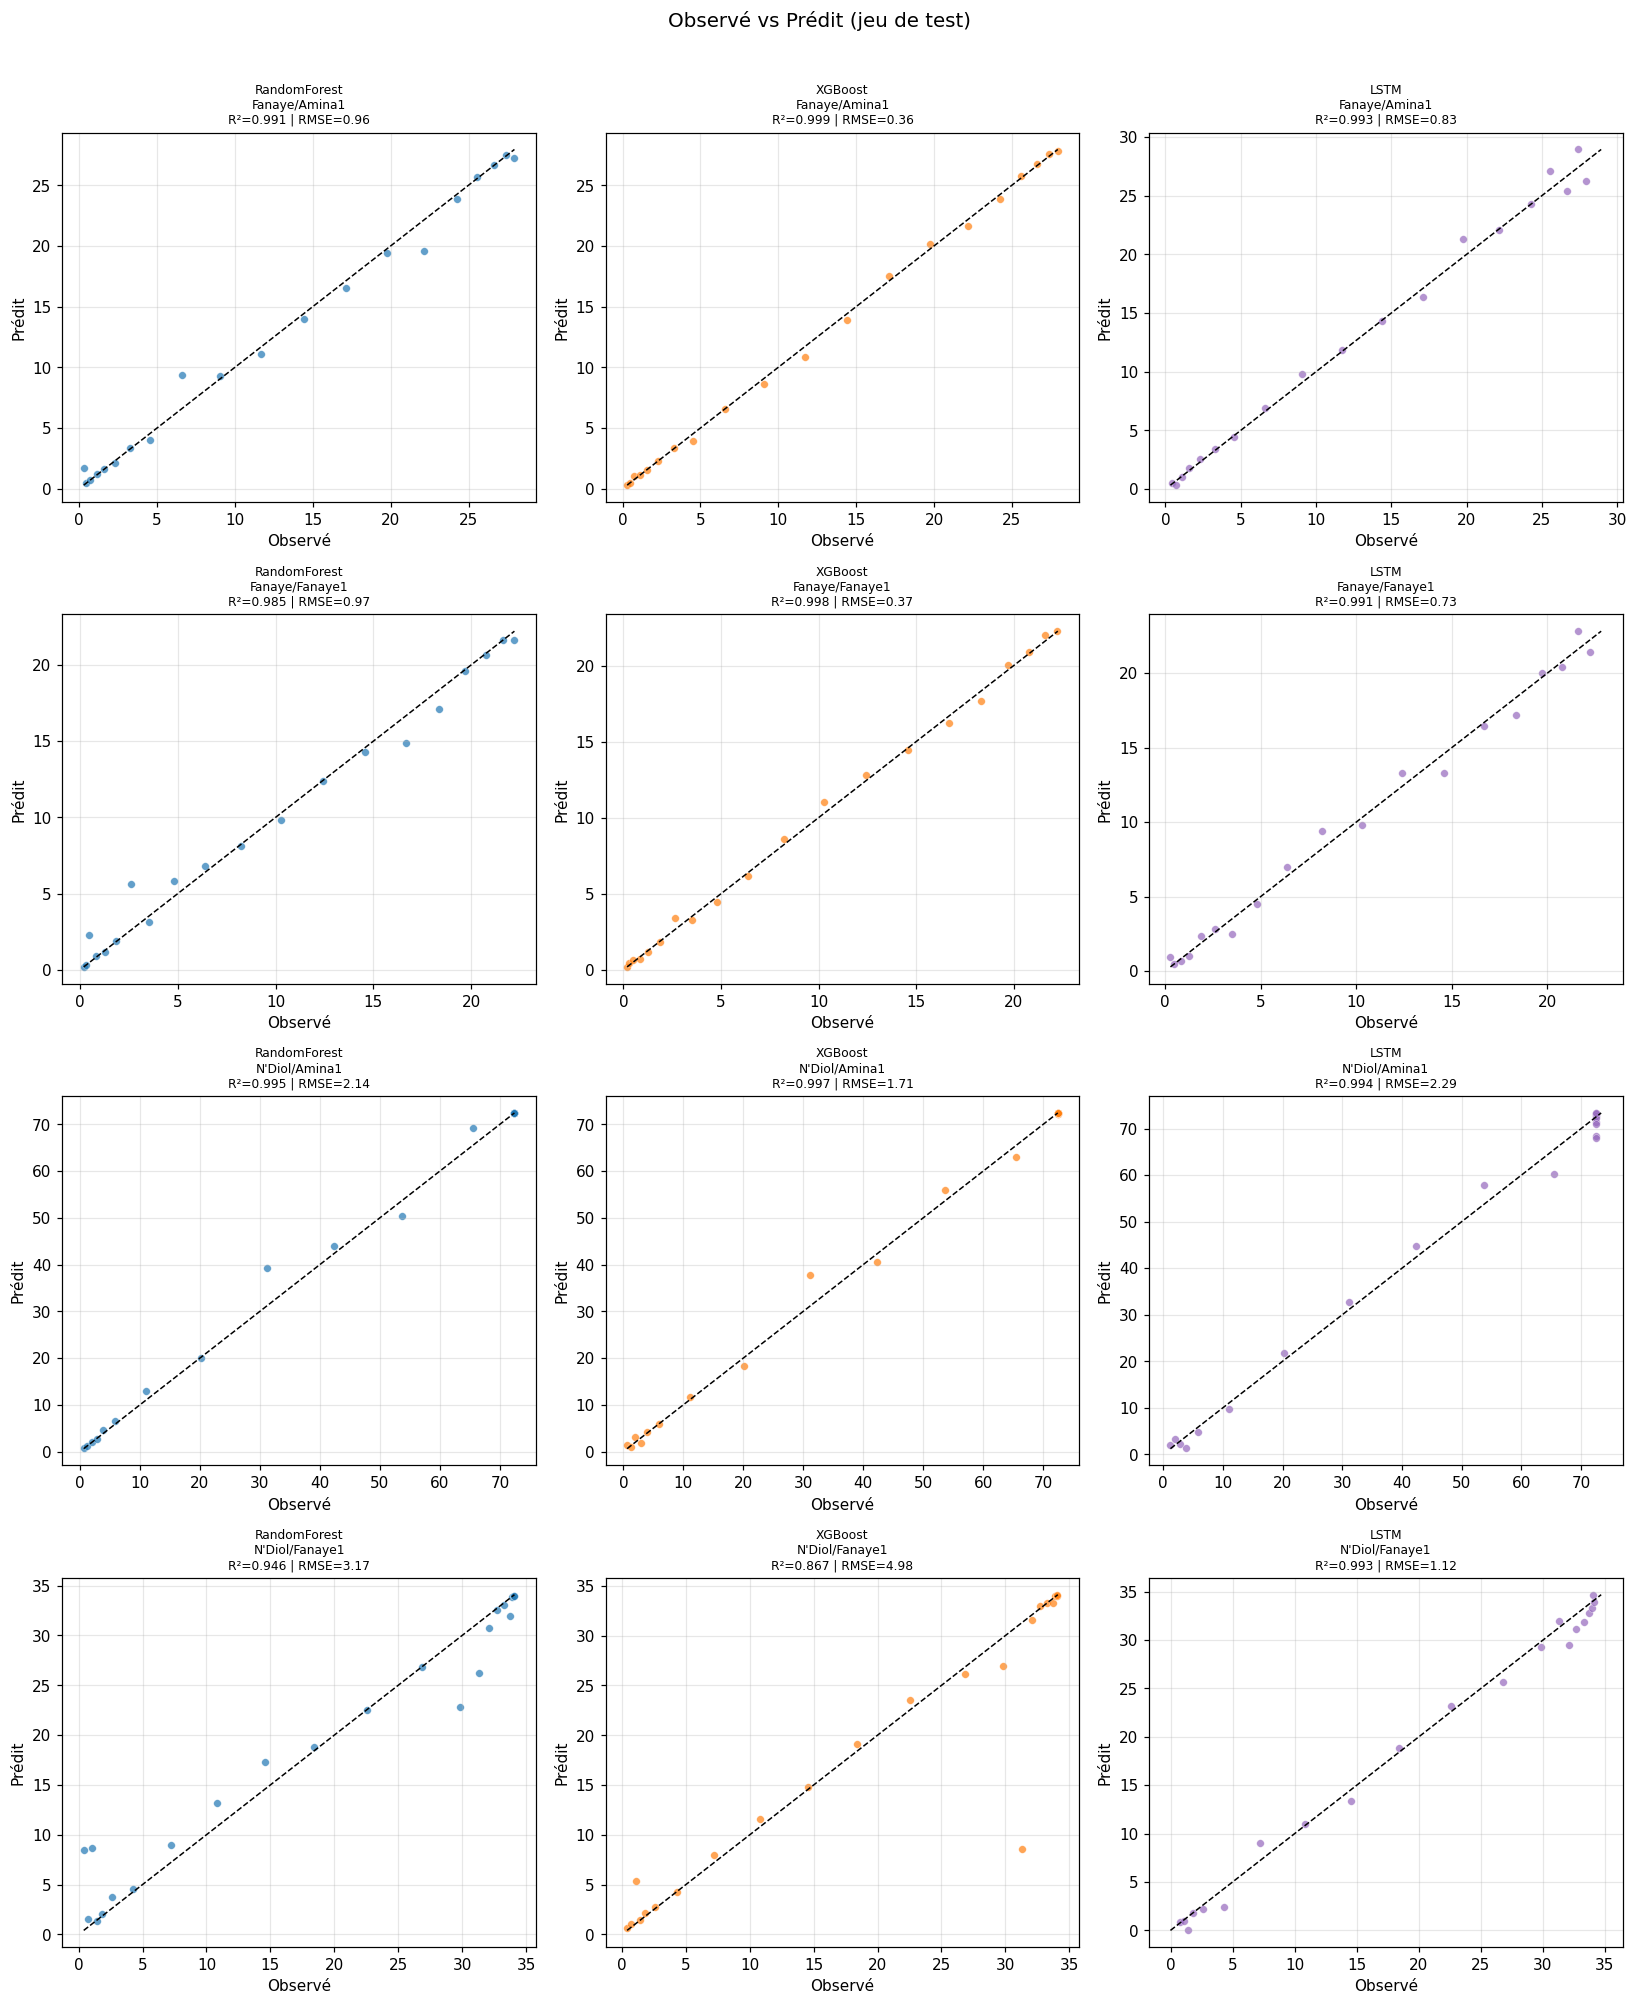

Figure sauvegardée : obs_vs_pred_all_models.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score

# Re-define model_colors to ensure it's available in this cell
model_colors = {'RandomForest': '#1f77b4', 'XGBoost': '#ff7f0e', 'LSTM': '#9467bd'}

fig, axes = plt.subplots(4, 3, figsize=(15, 18))

for row, (group_name, site, variete) in enumerate(GROUPS):
    for col, model_type in enumerate(['RandomForest', 'XGBoost', 'LSTM']):
        ax  = axes[row, col]
        pdf = predictions_store[(model_type, group_name)]
        test_mask = pdf['split'] == 'test'

        obs  = pdf.loc[test_mask, 'biomasse_obs']
        pred = pdf.loc[test_mask, 'biomasse_pred']

        ax.scatter(obs, pred, alpha=0.7, s=25,
                   color=model_colors[model_type], edgecolors='white', linewidth=0.3)

        mn = min(obs.min(), pred.min())
        mx = max(obs.max(), pred.max())
        ax.plot([mn, mx], [mn, mx], 'k--', linewidth=1, label='Idéal')

        r2   = r2_score(obs, pred)
        rmse = np.sqrt(mean_squared_error(obs, pred))
        ax.set_title(f"{model_type}\n{site}/{variete}\nR²={r2:.3f} | RMSE={rmse:.2f}",
                     fontsize=8)
        ax.set_xlabel("Observé"); ax.set_ylabel("Prédit")
        ax.grid(alpha=0.3)

plt.suptitle("Observé vs Prédit (jeu de test)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('obs_vs_pred_all_models.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : obs_vs_pred_all_models.png")

### 5.2 Histogrammes des résidus

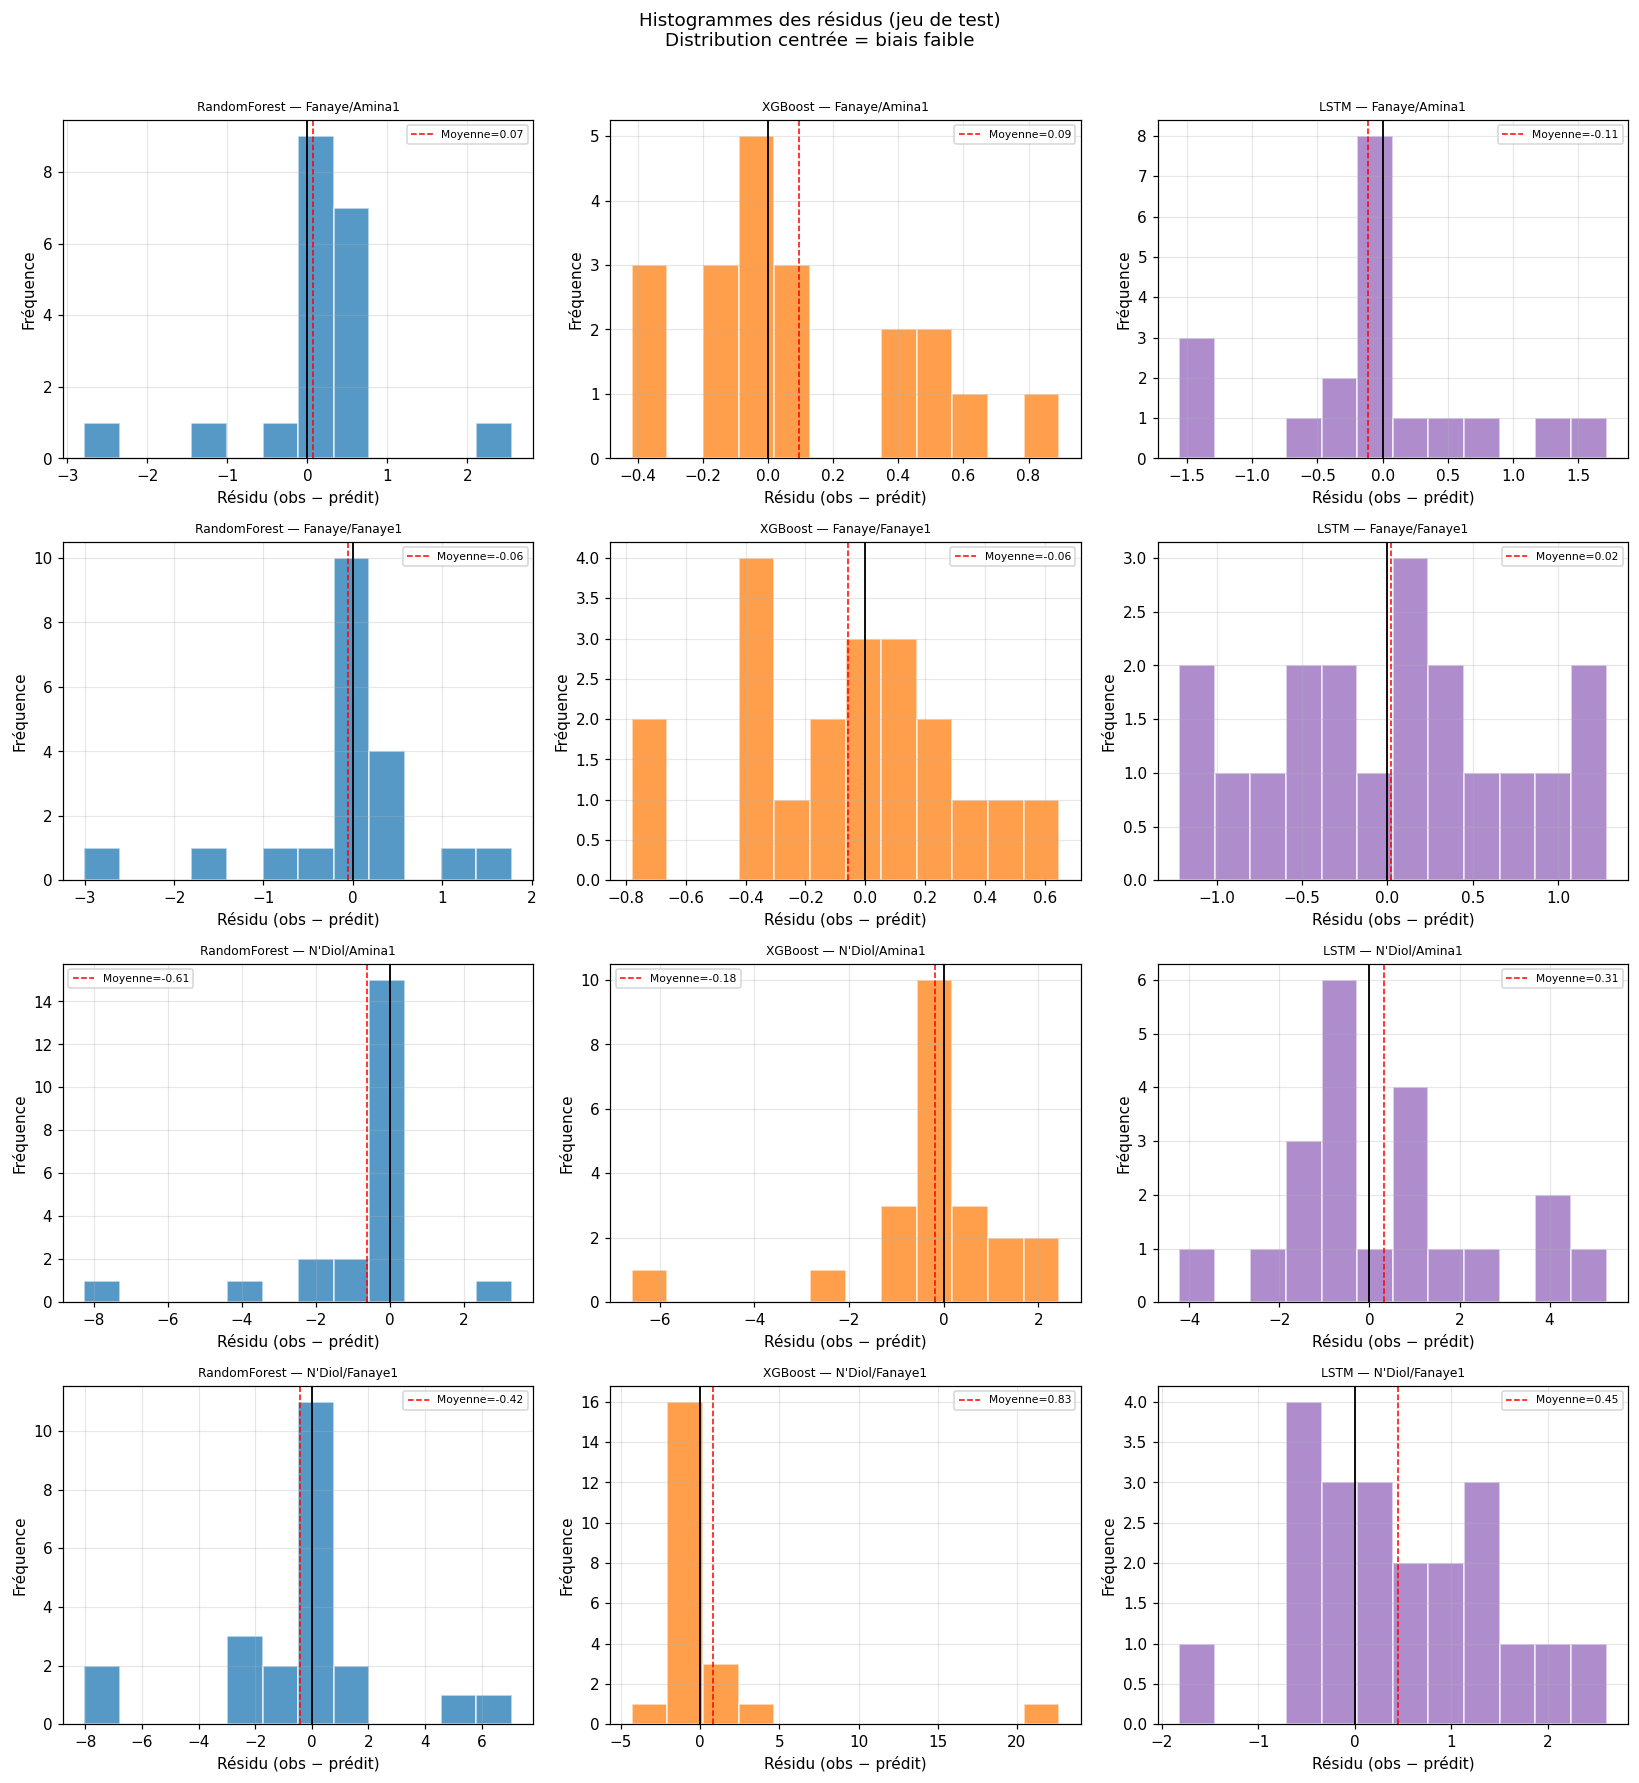

Figure sauvegardée : residuals_histograms.png


In [ ]:
fig, axes = plt.subplots(4, 3, figsize=(15, 16))

for row, (group_name, site, variete) in enumerate(GROUPS):
    for col, model_type in enumerate(['RandomForest', 'XGBoost', 'LSTM']):
        ax  = axes[row, col]
        pdf = predictions_store[(model_type, group_name)]
        test_mask = pdf['split'] == 'test'
        residuals = (pdf.loc[test_mask, 'biomasse_obs']
                     - pdf.loc[test_mask, 'biomasse_pred'])

        ax.hist(residuals, bins=12, color=model_colors[model_type],
                alpha=0.75, edgecolor='white')
        ax.axvline(0, color='black', linewidth=1.2)
        ax.axvline(residuals.mean(), color='red', linestyle='--', linewidth=1,
                   label=f'Moyenne={residuals.mean():.2f}')
        ax.set_title(f"{model_type} — {site}/{variete}", fontsize=8)
        ax.set_xlabel("Résidu (obs − prédit)"); ax.set_ylabel("Fréquence")
        ax.legend(fontsize=7); ax.grid(alpha=0.3)

plt.suptitle("Histogrammes des résidus (jeu de test)\n"
             "Distribution centrée = biais faible", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('residuals_histograms.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : residuals_histograms.png")

### 5.3 Dynamiques temporelles de croissance — tous modèles

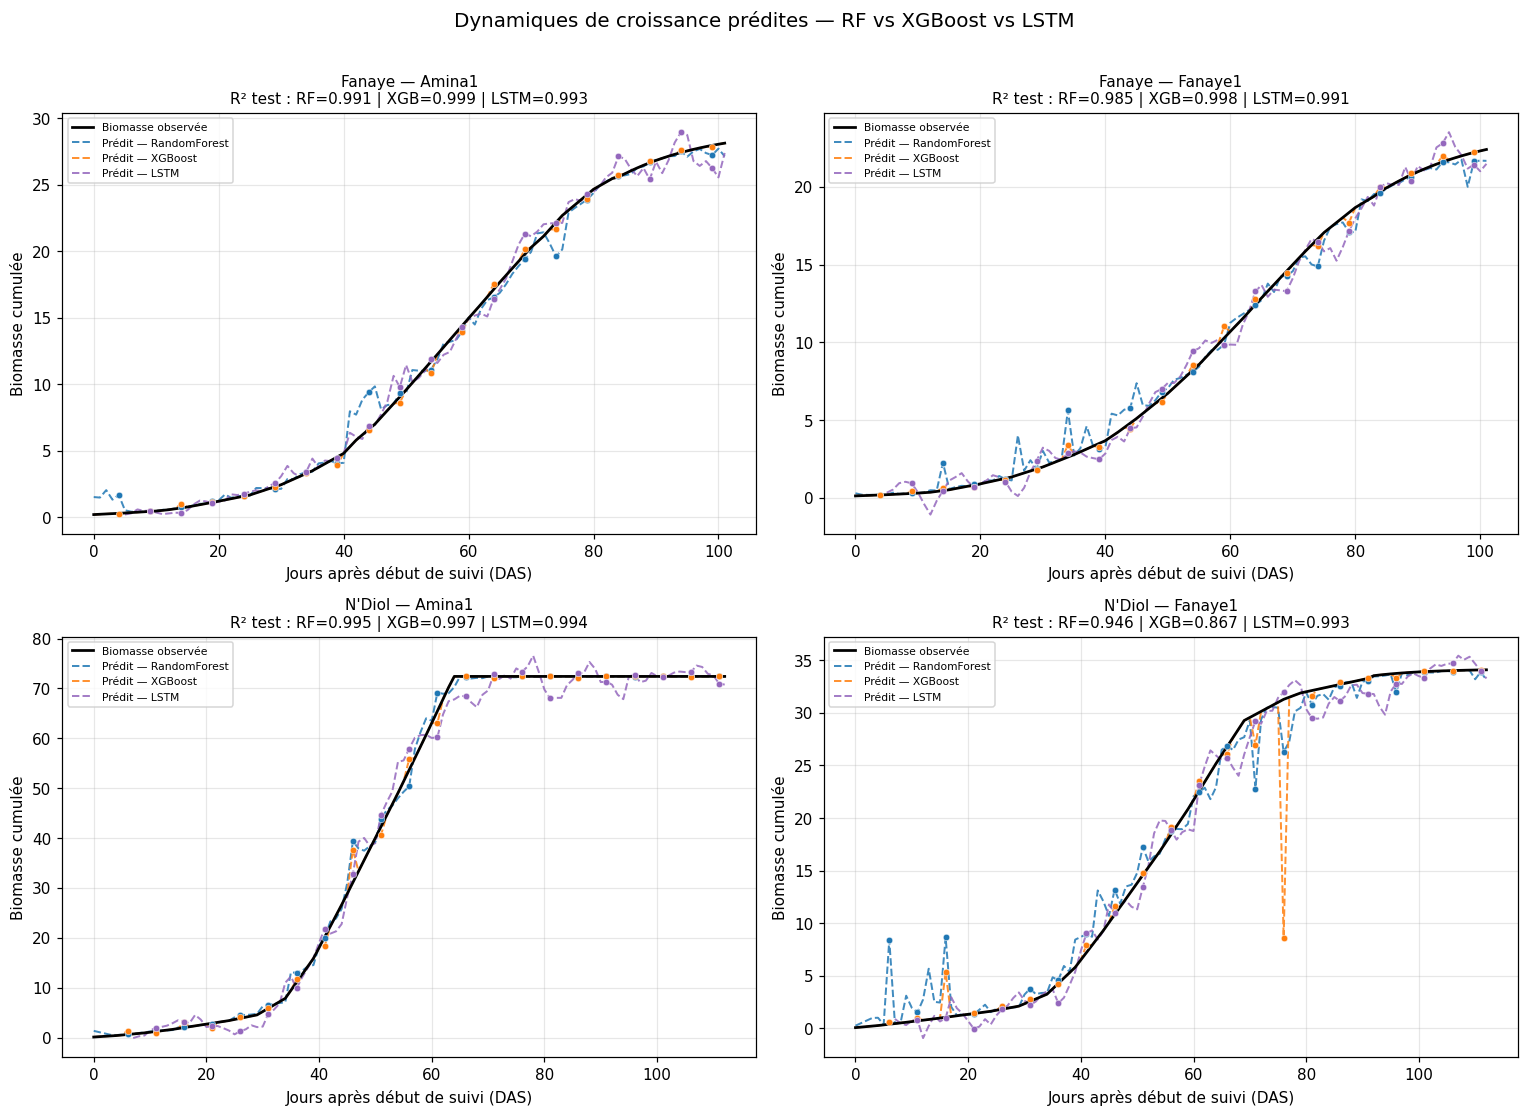

Figure sauvegardée : growth_dynamics_all_models.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for ax, (group_name, site, variete) in zip(axes, GROUPS):
    obs_ref = predictions_store[('RandomForest', group_name)]
    ax.plot(obs_ref['das'], obs_ref['biomasse_obs'],
            color='black', linewidth=1.8, label='Biomasse observée', zorder=3)

    for model_type in ['RandomForest', 'XGBoost', 'LSTM']:
        pdf = predictions_store[(model_type, group_name)]
        ax.plot(pdf['das'], pdf['biomasse_pred_full'],
                color=model_colors[model_type], linestyle='--',
                linewidth=1.3, label=f'Prédit — {model_type}', alpha=0.85)
        test_mask = pdf['split'] == 'test'
        ax.scatter(pdf.loc[test_mask, 'das'], pdf.loc[test_mask, 'biomasse_pred'],
                   color=model_colors[model_type], s=18, zorder=4,
                   edgecolor='white', linewidth=0.3)

    r2_rf  = results_df[(results_df.Groupe == f"{site} / {variete}") &
                        (results_df.Modèle == 'RandomForest')]['R²'].values[0]
    r2_xgb = results_df[(results_df.Groupe == f"{site} / {variete}") &
                        (results_df.Modèle == 'XGBoost')]['R²'].values[0]
    r2_lstm = results_df[(results_df.Groupe == f"{site} / {variete}") &
                         (results_df.Modèle == 'LSTM')]['R²'].values[0]

    ax.set_title(f"{site} — {variete}\n"
                 f"R² test : RF={r2_rf:.3f} | XGB={r2_xgb:.3f} | LSTM={r2_lstm:.3f}",
                 fontsize=10)
    ax.set_xlabel("Jours après début de suivi (DAS)")
    ax.set_ylabel("Biomasse cumulée")
    ax.legend(fontsize=7, loc='upper left'); ax.grid(alpha=0.3)

plt.suptitle("Dynamiques de croissance prédites — RF vs XGBoost vs LSTM",
             y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig('growth_dynamics_all_models.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : growth_dynamics_all_models.png")

---
## Partie 6 — Importance des variables

### 6.1 Feature importances — Random Forest et XGBoost


In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(14, 20))

for row, (group_name, site, variete) in enumerate(GROUPS):
    for col, model_type in enumerate(['RandomForest', 'XGBoost']):
        ax  = axes[row, col]
        imp = feature_importance_store[(model_type, group_name)]
        ax.barh(imp['Feature'][::-1], imp['Importance'][::-1],
                color=model_colors[model_type], alpha=0.85)
        ax.set_title(f"{model_type} — {site}/{variete}", fontsize=9)
        ax.set_xlabel("Importance"); ax.grid(alpha=0.3, axis='x')

plt.suptitle("Importance des variables\n"
             "Confirmation que les features sélectionnées contribuent réellement",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('feature_importances.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : feature_importances.png")

---
## Partie 7 — Validation croisée phénologique (5 folds)

### 7.1 Fonction de découpage phénologique


In [ ]:
def phenological_cv_split(n, n_folds=5):
    """Découpe la série en n_folds blocs consécutifs.
    Chaque fold retire un bloc différent pour le test.
    Pas de leakage temporel : les folds couvrent tout le cycle.
    """
    fold_size = n // n_folds
    splits    = []
    for i in range(n_folds):
        test_start = i * fold_size
        test_end   = test_start + fold_size
        test_idx   = np.arange(test_start, min(test_end, n))
        train_idx  = np.array([j for j in range(n) if j not in test_idx])
        splits.append((train_idx, test_idx))
    return splits

print("✅ Fonction 'phenological_cv_split' définie.")

### 7.2 CV phénologique — Random Forest et XGBoost

In [ ]:
N_SPLITS  = 3
cv_results = []

for group_name, site, variete in GROUPS:
    subset = (df[(df['site'] == site) & (df['variete'] == variete)]
              .copy().sort_values('date').reset_index(drop=True))
    features = get_features(subset)
    X = subset[features].values
    y = subset['biomasse_cum'].values
    n = len(X)

    for model_type, ModelClass, kwargs in [
        ('RandomForest', RandomForestRegressor,
         dict(n_estimators=200, max_depth=8, min_samples_leaf=2,
              random_state=SEED, n_jobs=-1)),
        ('XGBoost', xgb.XGBRegressor,
         dict(n_estimators=200, learning_rate=0.1, max_depth=5,
              random_state=SEED, verbosity=0)),
    ]:
        all_obs, all_pred = [], []

        for train_idx, test_idx in phenological_cv_split(n, N_SPLITS):
            if len(test_idx) < 2 or len(train_idx) < 2:
                continue
            m = ModelClass(**kwargs)
            if model_type == 'XGBoost':
                m.fit(X[train_idx], y[train_idx],
                      eval_set=[(X[train_idx], y[train_idx])], verbose=False)
            else:
                m.fit(X[train_idx], y[train_idx])
            all_obs.extend(y[test_idx])
            all_pred.extend(m.predict(X[test_idx]))

        all_obs  = np.array(all_obs)
        all_pred = np.array(all_pred)
        mask     = ~(np.isnan(all_obs) | np.isnan(all_pred))

        cv_results.append({
            'Modèle':      model_type,
            'Groupe':      f"{site} / {variete}",
            'R²_global':   r2_score(all_obs[mask], all_pred[mask]),
            'RMSE_global': np.sqrt(mean_squared_error(all_obs[mask], all_pred[mask])),
            'MAE_global':  mean_absolute_error(all_obs[mask], all_pred[mask]),
        })

cv_df = pd.DataFrame(cv_results)
print("Résultats CV phénologique (RF & XGBoost) :")
display(cv_df.round(4))

### 7.3 CV R² par fold — visualisation

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for ax, (group_name, site, variete) in zip(axes, GROUPS):
    subset = (df[(df['site'] == site) & (df['variete'] == variete)]
              .copy().sort_values('date').reset_index(drop=True))
    features = get_features(subset)
    X = subset[features].values
    y = subset['biomasse_cum'].values
    n = len(X)

    for model_type, ModelClass, kwargs, color in [
        ('RandomForest', RandomForestRegressor,
         dict(n_estimators=200, max_depth=8, min_samples_leaf=2,
              random_state=SEED, n_jobs=-1),
         model_colors['RandomForest']),
        ('XGBoost', xgb.XGBRegressor,
         dict(n_estimators=100, learning_rate=0.1, max_depth=5,
              random_state=SEED, verbosity=0),
         model_colors['XGBoost']),
    ]:
        fold_r2 = []
        for tr_idx, te_idx in phenological_cv_split(n, N_SPLITS):
            if len(te_idx) < 3:
                fold_r2.append(np.nan); continue
            m = ModelClass(**kwargs)
            m.fit(X[tr_idx], y[tr_idx])
            fold_r2.append(r2_score(y[te_idx], m.predict(X[te_idx])))

        valid_folds = [i+1 for i, v in enumerate(fold_r2) if not np.isnan(v)]
        valid_r2    = [v for v in fold_r2 if not np.isnan(v)]
        ax.plot(valid_folds, valid_r2, marker='o', color=color,
                linewidth=1.5, markersize=6, label=model_type)
        if valid_r2:
            ax.axhline(np.mean(valid_r2), color=color, linestyle='--',
                       alpha=0.5, linewidth=1)

    ax.axhline(0.9, color='gray', linestyle=':', linewidth=1, label='Seuil 0.9')
    ax.set_title(f"{site} / {variete}", fontsize=10)
    ax.set_xlabel("Fold (chronologique)"); ax.set_ylabel("R² (test)")
    ax.set_ylim(-0.2, 1.05); ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle(f"Validation croisée phénologique ({N_SPLITS} folds) — R² par fold\n"
             "Stabilité entre folds = robustesse du modèle", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('cv_temporal_r2.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : cv_temporal_r2.png")

---
## Partie 7bis — Optimisation des hyperparamètres par CV phénologique

### Stratégie

La CV phénologique remplace le `cv` standard de `GridSearchCV` :
chaque fold retire un **bloc temporel consécutif** du cycle, ce qui évite
tout data leakage par proximité temporelle.

On définit un **scorer personnalisé** basé sur cette CV, utilisé pour :
- **Random Forest** : GridSearchCV exhaustif (36 combinaisons)  
- **XGBoost** : RandomizedSearchCV (30 tirages, espace plus grand)  
- **LSTM** : grille manuelle (architecture + dropout + batch_size)

Le **meilleur modèle par groupe** est ensuite réentraîné sur toutes les données
d'entraînement (split systématique) et comparé aux modèles de base.


In [ ]:
from sklearn.model_selection import BaseCrossValidator, ParameterGrid, RandomizedSearchCV
from sklearn.base import clone
from scipy.stats import randint, uniform
import itertools, time

# ══════════════════════════════════════════════════════════════════════════════
# CV phénologique compatible sklearn (BaseCrossValidator)
# ══════════════════════════════════════════════════════════════════════════════

class PhenologicalCV(BaseCrossValidator):
    """Validation croisée phénologique compatible sklearn.

    Découpe la série en n_splits blocs consécutifs.
    Chaque fold retire un bloc différent pour le test.
    Compatible avec GridSearchCV et RandomizedSearchCV.
    """
    def __init__(self, n_splits=5):
        self.n_splits = n_splits

    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits

    def split(self, X, y=None, groups=None):
        n         = len(X)
        fold_size = n // self.n_splits
        for i in range(self.n_splits):
            ts        = i * fold_size
            te        = ts + fold_size
            test_idx  = np.arange(ts, min(te, n))
            train_idx = np.array([j for j in range(n) if j not in test_idx])
            # Garantir qu'aucun fold n'est vide
            if len(train_idx) >= 2 and len(test_idx) >= 2:
                yield train_idx, test_idx

    def _iter_test_indices(self, X=None, y=None, groups=None):
        # Requis par BaseCrossValidator (non utilisé directement)
        for _, test in self.split(X, y):
            yield test

pheno_cv = PhenologicalCV(n_splits=5)
print("✅ PhenologicalCV défini (n_splits=5).")
print(f"   Compatible GridSearchCV / RandomizedSearchCV.")

✅ PhenologicalCV défini (n_splits=5).
   Compatible GridSearchCV / RandomizedSearchCV.


### 7bis.1 Optimisation Random Forest — GridSearchCV exhaustif

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

# ── Grille RF ─────────────────────────────────────────────────────────────────
RF_PARAM_GRID = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [5, 8, 10, None],
    'min_samples_leaf': [1, 2, 4],
}
print(f"Grille RF : {len(list(ParameterGrid(RF_PARAM_GRID)))} combinaisons × {pheno_cv.n_splits} folds")

scorer_r2   = make_scorer(r2_score)
scorer_rmse = make_scorer(mean_squared_error, greater_is_better=False,
                           squared=False)

rf_best_models   = {}
rf_best_params   = {}
rf_cv_results_df = []

for group_name, site, variete in GROUPS:
    t0 = time.time()
    subset = (df[(df['site'] == site) & (df['variete'] == variete)]
              .copy().sort_values('date').reset_index(drop=True))
    features = get_features(subset)
    valid    = subset['biomasse_cum'].notna()
    X        = subset.loc[valid, features].values
    y        = subset.loc[valid, 'biomasse_cum'].values

    gs = GridSearchCV(
        estimator  = RandomForestRegressor(random_state=SEED, n_jobs=-1,
                                            oob_score=True),
        param_grid = RF_PARAM_GRID,
        cv         = pheno_cv,
        scoring    = 'r2',
        refit      = True,         # réentraîne sur tout X avec best params
        n_jobs     = -1,
        verbose    = 0,
    )
    gs.fit(X, y)

    rf_best_models[group_name] = gs.best_estimator_
    rf_best_params[group_name] = gs.best_params_

    # Métriques sur le jeu de test (split systématique)
    train_idx, test_idx = systematic_temporal_split(len(X))
    y_pred_test  = gs.best_estimator_.predict(X[test_idx])
    y_pred_train = gs.best_estimator_.predict(X[train_idx])

    rf_cv_results_df.append({
        'Groupe':        f"{site} / {variete}",
        'best_params':   gs.best_params_,
        'CV_R²_mean':    gs.best_score_,
        'CV_R²_std':     gs.cv_results_['std_test_score'][gs.best_index_],
        'R²_test':       r2_score(y[test_idx], y_pred_test),
        'RMSE_test':     np.sqrt(mean_squared_error(y[test_idx], y_pred_test)),
        'MAE_test':      mean_absolute_error(y[test_idx], y_pred_test),
        'R²_train':      r2_score(y[train_idx], y_pred_train),
    })

    elapsed = time.time() - t0
    print(f"  [{group_name}] Best R²_CV={gs.best_score_:.4f} | "
          f"R²_test={rf_cv_results_df[-1]['R²_test']:.4f} | "
          f"Params={gs.best_params_} | {elapsed:.1f}s")

rf_opt_df = pd.DataFrame(rf_cv_results_df)
print("\n✅ Optimisation RF terminée.")
display(rf_opt_df[['Groupe','CV_R²_mean','CV_R²_std',
                    'R²_train','R²_test','RMSE_test','MAE_test']].round(4))

Grille RF : 36 combinaisons × 5 folds
  [Fanaye_Amina1] Best R²_CV=-399.1035 | R²_test=0.9978 | Params={'max_depth': 8, 'min_samples_leaf': 2, 'n_estimators': 300} | 86.5s
  [Fanaye_Fanaye1] Best R²_CV=-54.8192 | R²_test=0.9984 | Params={'max_depth': 5, 'min_samples_leaf': 1, 'n_estimators': 200} | 84.0s
  [NDiol_Amina1] Best R²_CV=-576298190829961392868162535424.0000 | R²_test=0.9993 | Params={'max_depth': 8, 'min_samples_leaf': 1, 'n_estimators': 100} | 82.0s
  [NDiol_Fanaye1] Best R²_CV=-361.9585 | R²_test=0.9958 | Params={'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 100} | 84.8s

✅ Optimisation RF terminée.


,Groupe,CV_R²_mean,CV_R²_std,R²_train,R²_test,RMSE_test,MAE_test
0,Fanaye / Amina1,-3.991035e+02,7.096679e+02,0.9967,0.9978,0.4845,0.2629
1,Fanaye / Fanaye1,-5.481920e+01,5.903510e+01,0.9975,0.9984,0.3204,0.1942
2,N'Diol / Amina1,-5.762982e+29,1.129516e+30,0.9997,0.9993,0.7827,0.3352
3,N'Diol / Fanaye1,-3.619585e+02,5.383301e+02,0.9937,0.9958,0.8910,0.5380


### 7bis.2 Optimisation XGBoost — RandomizedSearchCV (30 tirages)

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# ── Espace de recherche XGB ───────────────────────────────────────────────────
XGB_PARAM_DIST = {
    'n_estimators':      randint(100, 400),
    'max_depth':         randint(3, 9),
    'learning_rate':     uniform(0.03, 0.25),   # [0.03, 0.28]
    'subsample':         uniform(0.6, 0.4),      # [0.6, 1.0]
    'colsample_bytree':  uniform(0.6, 0.4),
    'min_child_weight':  randint(1, 6),
    'gamma':             uniform(0, 0.3),
    'reg_alpha':         uniform(0, 0.5),        # L1
    'reg_lambda':        uniform(0.5, 1.5),      # L2
}
N_ITER_SEARCH = 30
print(f"Recherche aléatoire XGB : {N_ITER_SEARCH} tirages × {pheno_cv.n_splits} folds")

xgb_best_models   = {}
xgb_best_params   = {}
xgb_cv_results_df = []

for group_name, site, variete in GROUPS:
    t0 = time.time()
    subset = (df[(df['site'] == site) & (df['variete'] == variete)]
              .copy().sort_values('date').reset_index(drop=True))
    features = get_features(subset)
    valid    = subset['biomasse_cum'].notna()
    X        = subset.loc[valid, features].values
    y        = subset.loc[valid, 'biomasse_cum'].values

    rs = RandomizedSearchCV(
        estimator          = xgb.XGBRegressor(random_state=SEED, verbosity=0,
                                               eval_metric='rmse'),
        param_distributions = XGB_PARAM_DIST,
        n_iter             = N_ITER_SEARCH,
        cv                 = pheno_cv,
        scoring            = 'r2',
        refit              = True,
        n_jobs             = -1,
        random_state       = SEED,
        verbose            = 0,
    )
    rs.fit(X, y)

    xgb_best_models[group_name] = rs.best_estimator_
    xgb_best_params[group_name] = rs.best_params_

    train_idx, test_idx = systematic_temporal_split(len(X))
    y_pred_test  = rs.best_estimator_.predict(X[test_idx])
    y_pred_train = rs.best_estimator_.predict(X[train_idx])

    xgb_cv_results_df.append({
        'Groupe':       f"{site} / {variete}",
        'best_params':  rs.best_params_,
        'CV_R²_mean':   rs.best_score_,
        'CV_R²_std':    rs.cv_results_['std_test_score'][rs.best_index_],
        'R²_test':      r2_score(y[test_idx], y_pred_test),
        'RMSE_test':    np.sqrt(mean_squared_error(y[test_idx], y_pred_test)),
        'MAE_test':     mean_absolute_error(y[test_idx], y_pred_test),
        'R²_train':     r2_score(y[train_idx], y_pred_train),
    })

    elapsed = time.time() - t0
    print(f"  [{group_name}] Best R²_CV={rs.best_score_:.4f} | "
          f"R²_test={xgb_cv_results_df[-1]['R²_test']:.4f} | {elapsed:.1f}s")
    bp = rs.best_params_
    print(f"    n_est={bp['n_estimators']} | depth={bp['max_depth']} | "
          f"lr={bp['learning_rate']:.3f} | sub={bp['subsample']:.2f}")

xgb_opt_df = pd.DataFrame(xgb_cv_results_df)
print("\n✅ Optimisation XGB terminée.")
display(xgb_opt_df[['Groupe','CV_R²_mean','CV_R²_std',
                     'R²_train','R²_test','RMSE_test','MAE_test']].round(4))

### 7bis.3 Optimisation LSTM — grille manuelle (architecture + régularisation)

In [ ]:
# ── Grille LSTM ───────────────────────────────────────────────────────────────
# GridSearchCV ne gère pas nativement Keras → boucle manuelle sur la grille
# avec la même CV phénologique

LSTM_PARAM_GRID = {
    'lstm_units':    [16, 32, 64],
    'dropout_rate':  [0.1, 0.2, 0.3],
    'batch_size':    [4, 8],
    'learning_rate': [1e-3, 5e-4],
}

# Grille réduite pour limiter le temps de calcul
# Total : 3×3×2×2 = 36 configs × 5 folds = 180 entraînements LSTM
# → utiliser n_splits=3 pour la grille LSTM
LSTM_N_SPLITS = 3
print(f"Grille LSTM : {np.prod([len(v) for v in LSTM_PARAM_GRID.values()])} configs "
      f"× {LSTM_N_SPLITS} folds = "
      f"{np.prod([len(v) for v in LSTM_PARAM_GRID.values()])*LSTM_N_SPLITS} entraînements")

def build_lstm_tunable(n_timesteps, n_features, lstm_units=32,
                        dropout_rate=0.2, learning_rate=1e-3):
    """LSTM paramétrable pour l'optimisation."""
    model = Sequential([
        LSTM(lstm_units, activation='tanh',
             input_shape=(n_timesteps, n_features)),
        Dropout(dropout_rate),
        Dense(max(8, lstm_units // 2), activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='mse', metrics=['mae'])
    return model

def pheno_cv_lstm_score(X_seq, y_seq, scaler_y,
                         n_timesteps, n_features, params, n_splits=3):
    """Score CV phénologique pour un jeu de paramètres LSTM.
    Retourne le R² moyen et la RMSE moyenne sur tous les folds valides.
    """
    pheno = PhenologicalCV(n_splits=n_splits)
    fold_r2, fold_rmse = [], []

    for train_idx, test_idx in pheno.split(X_seq):
        if len(train_idx) < params['batch_size'] + 1 or len(test_idx) < 2:
            continue

        tf.random.set_seed(SEED)
        m = build_lstm_tunable(n_timesteps, n_features, **{
            k: params[k] for k in ['lstm_units', 'dropout_rate', 'learning_rate']
        })
        early_stop = EarlyStopping(monitor='val_loss', patience=10,
                                    restore_best_weights=True, verbose=0)
        m.fit(X_seq[train_idx], y_seq[train_idx],
              epochs=100, batch_size=params['batch_size'],
              verbose=0, callbacks=[early_stop],
              validation_data=(X_seq[test_idx], y_seq[test_idx]))

        pred_sc    = m.predict(X_seq[test_idx], verbose=0).flatten()
        y_test_r   = scaler_y.inverse_transform(
                         y_seq[test_idx].reshape(-1, 1)).flatten()
        pred_r     = scaler_y.inverse_transform(
                         pred_sc.reshape(-1, 1)).flatten()

        if np.var(y_test_r) > 0:
            fold_r2.append(r2_score(y_test_r, pred_r))
        fold_rmse.append(np.sqrt(mean_squared_error(y_test_r, pred_r)))

        tf.keras.backend.clear_session()   # libérer la mémoire GPU/CPU

    if not fold_r2:
        return -np.inf, np.inf
    return np.mean(fold_r2), np.mean(fold_rmse)

print("✅ Fonctions d'optimisation LSTM définies.")

In [ ]:
# ── Recherche sur la grille LSTM ─────────────────────────────────────────────
lstm_best_models_opt  = {}
lstm_best_params_opt  = {}
lstm_cv_results_df    = []

all_configs = list(ParameterGrid(LSTM_PARAM_GRID))
print(f"Lancement : {len(all_configs)} configurations × {LSTM_N_SPLITS} folds\n")

for group_name, site, variete in GROUPS:
    t0 = time.time()
    print(f"{'='*60}")
    print(f"Optimisation LSTM — {site} / {variete}")
    print(f"{'='*60}")

    subset = (df[(df['site'] == site) & (df['variete'] == variete)]
              .copy().sort_values('date').reset_index(drop=True))
    features   = get_features(subset)
    X_raw      = subset[features].values
    y_raw      = subset['biomasse_cum'].values

    scaler_X   = MinMaxScaler()
    X_scaled   = scaler_X.fit_transform(X_raw)
    scaler_y_g = MinMaxScaler()
    y_scaled   = scaler_y_g.fit_transform(y_raw.reshape(-1, 1)).flatten()

    X_seq, y_seq = make_sequences(X_scaled, y_scaled, WINDOW)
    n_ts, n_feat = WINDOW, X_seq.shape[2]

    best_r2     = -np.inf
    best_rmse   = np.inf
    best_params = None
    grid_log    = []

    for cfg in all_configs:
        r2_cv, rmse_cv = pheno_cv_lstm_score(
            X_seq, y_seq, scaler_y_g, n_ts, n_feat, cfg, LSTM_N_SPLITS)
        grid_log.append({**cfg, 'CV_R²': r2_cv, 'CV_RMSE': rmse_cv})
        if r2_cv > best_r2:
            best_r2     = r2_cv
            best_rmse   = rmse_cv
            best_params = cfg

    # Réentraîner le meilleur modèle sur le split systématique complet
    train_idx, test_idx = systematic_temporal_split(len(X_seq))
    tf.random.set_seed(SEED)
    best_model = build_lstm_tunable(n_ts, n_feat, **{
        k: best_params[k] for k in ['lstm_units', 'dropout_rate', 'learning_rate']
    })
    early_stop = EarlyStopping(monitor='val_loss', patience=15,
                                restore_best_weights=True, verbose=0)
    best_model.fit(
        X_seq[train_idx], y_seq[train_idx],
        epochs=150, batch_size=best_params['batch_size'],
        verbose=0, callbacks=[early_stop],
        validation_data=(X_seq[test_idx], y_seq[test_idx])
    )

    def inv_y(arr):
        return scaler_y_g.inverse_transform(arr.reshape(-1, 1)).flatten()

    y_pred_test  = inv_y(best_model.predict(X_seq[test_idx],  verbose=0).flatten())
    y_pred_train = inv_y(best_model.predict(X_seq[train_idx], verbose=0).flatten())
    y_test_real  = inv_y(y_seq[test_idx])
    y_train_real = inv_y(y_seq[train_idx])

    lstm_best_models_opt[group_name] = best_model
    lstm_best_params_opt[group_name] = best_params

    lstm_cv_results_df.append({
        'Groupe':      f"{site} / {variete}",
        'best_params': best_params,
        'CV_R²_mean':  best_r2,
        'CV_RMSE':     best_rmse,
        'R²_test':     r2_score(y_test_real, y_pred_test),
        'RMSE_test':   np.sqrt(mean_squared_error(y_test_real, y_pred_test)),
        'MAE_test':    mean_absolute_error(y_test_real, y_pred_test),
        'R²_train':    r2_score(y_train_real, y_pred_train),
        'scalers':     (scaler_X, scaler_y_g, features),
    })

    elapsed = time.time() - t0
    print(f"  Best R²_CV={best_r2:.4f} | R²_test={lstm_cv_results_df[-1]['R²_test']:.4f} | "
          f"{elapsed:.1f}s")
    print(f"  Best params: units={best_params['lstm_units']} | "
          f"dropout={best_params['dropout_rate']} | "
          f"batch={best_params['batch_size']} | lr={best_params['learning_rate']}")
    # Afficher le top-3
    grid_log_df = pd.DataFrame(grid_log).sort_values('CV_R²', ascending=False)
    print(f"  Top-3 configs CV :")
    print(grid_log_df.head(3)[
        ['lstm_units','dropout_rate','batch_size','learning_rate','CV_R²','CV_RMSE']
    ].round(4).to_string(index=False))
    print()

lstm_opt_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'scalers'}
                              for r in lstm_cv_results_df])
print("\n✅ Optimisation LSTM terminée.")
display(lstm_opt_df[['Groupe','CV_R²_mean','CV_RMSE',
                      'R²_train','R²_test','RMSE_test','MAE_test']].round(4))

### 7bis.4 Comparaison modèles de base vs modèles optimisés

In [ ]:
# ── Tableau comparatif base vs optimisé ──────────────────────────────────────
print("=" * 90)
print("COMPARAISON BASE vs OPTIMISÉ — R² test (split systématique)")
print("=" * 90)

compare_rows = []
for group_name, site, variete in GROUPS:
    groupe = f"{site} / {variete}"
    for model_type, opt_df in [('RandomForest', rf_opt_df),
                                 ('XGBoost',     xgb_opt_df),
                                 ('LSTM',         lstm_opt_df)]:
        # Base (résultats initiaux)
        base_row = results_df[(results_df.Groupe == groupe) &
                               (results_df.Modèle == model_type)]
        if len(base_row) == 0:
            continue
        r2_base = base_row['R²'].values[0]
        rmse_base = base_row['RMSE'].values[0]

        # Optimisé
        opt_row = opt_df[opt_df['Groupe'] == groupe]
        if len(opt_row) == 0:
            continue
        r2_opt  = opt_row['R²_test'].values[0]
        rmse_opt = opt_row['RMSE_test'].values[0]

        delta_r2   = r2_opt - r2_base
        delta_rmse = rmse_opt - rmse_base

        compare_rows.append({
            'Modèle':      model_type,
            'Groupe':      groupe,
            'R²_base':     r2_base,
            'R²_opt':      r2_opt,
            'ΔR²':         delta_r2,
            'RMSE_base':   rmse_base,
            'RMSE_opt':    rmse_opt,
            'ΔRMSE':       delta_rmse,
            'Amélioration': '✅' if delta_r2 > 0 else '⬇'
        })

compare_df = pd.DataFrame(compare_rows)
display(compare_df.round(4))

print("\nMoyenne ΔR² par modèle (positif = amélioration) :")
display(compare_df.groupby('Modèle')['ΔR²'].mean().round(4))

In [ ]:
# ── Graphique comparatif ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, model_type in zip(axes, ['RandomForest', 'XGBoost', 'LSTM']):
    sub = compare_df[compare_df.Modèle == model_type]
    x   = np.arange(len(sub))
    w   = 0.35

    bars_base = ax.bar(x - w/2, sub['R²_base'], w, label='Base',
                        color='#aec7e8', edgecolor='white')
    bars_opt  = ax.bar(x + w/2, sub['R²_opt'],  w, label='Optimisé',
                        color=model_colors[model_type], edgecolor='white', alpha=0.9)

    for bar in bars_opt:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

    ax.axhline(0.9, color='gray', linestyle='--', linewidth=1, alpha=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels([g.replace(' / ', '\n') for g in sub['Groupe']],
                        fontsize=8, rotation=10)
    ax.set_ylim(0, 1.12); ax.set_ylabel("R² test"); ax.set_title(model_type)
    ax.legend(fontsize=8); ax.grid(alpha=0.3, axis='y')

plt.suptitle("R² test : Modèles de base vs Modèles optimisés (CV phénologique)",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('base_vs_optimized_r2.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : base_vs_optimized_r2.png")

### 7bis.5 Meilleurs hyperparamètres — récapitulatif

In [ ]:
print("=" * 70)
print("MEILLEURS HYPERPARAMÈTRES PAR GROUPE")
print("=" * 70)

for group_name, site, variete in GROUPS:
    groupe = f"{site} / {variete}"
    print(f"\n  ── {groupe} ──")

    # RF
    rf_p = rf_best_params[group_name]
    rf_r = rf_opt_df[rf_opt_df.Groupe == groupe]['R²_test'].values[0]
    print(f"  Random Forest : n_est={rf_p['n_estimators']} | "
          f"max_depth={rf_p['max_depth']} | "
          f"min_samples_leaf={rf_p['min_samples_leaf']} | R²_test={rf_r:.4f}")

    # XGB
    xgb_p = xgb_best_params[group_name]
    xgb_r = xgb_opt_df[xgb_opt_df.Groupe == groupe]['R²_test'].values[0]
    print(f"  XGBoost       : n_est={xgb_p['n_estimators']} | "
          f"depth={xgb_p['max_depth']} | "
          f"lr={xgb_p['learning_rate']:.3f} | "
          f"sub={xgb_p['subsample']:.2f} | R²_test={xgb_r:.4f}")

    # LSTM
    lstm_p = lstm_best_params_opt[group_name]
    lstm_r = lstm_opt_df[lstm_opt_df.Groupe == groupe]['R²_test'].values[0]
    print(f"  LSTM          : units={lstm_p['lstm_units']} | "
          f"dropout={lstm_p['dropout_rate']} | "
          f"batch={lstm_p['batch_size']} | "
          f"lr={lstm_p['learning_rate']} | R²_test={lstm_r:.4f}")

### 7bis.6 Sauvegarde des modèles LSTM optimisés et de leurs scalers

In [ ]:
display(compare_df)

In [ ]:
import json
import os
import joblib
from tensorflow.keras.models import save_model

os.makedirs('models_optimized_lstm', exist_ok=True)

saved_optimized_lstm_files = []

for group_name, model in lstm_best_models_opt.items():
    # Sauvegarde du modèle Keras optimisé
    path_keras = f'models_optimized_lstm/lstm_optimized_{group_name}.keras'
    save_model(model, path_keras)
    saved_optimized_lstm_files.append(path_keras)
    print(f"✅ Modèle LSTM optimisé sauvegardé : {path_keras}")

    # Récupération et sauvegarde des scalers pour ce groupe
    # Les scalers sont stockés dans lstm_cv_results_df
    group_result = None
    for item in lstm_cv_results_df:
        if item["Groupe"] == group_name.replace('_', ' / '):
            group_result = item
            break

    if group_result:
        scaler_X, scaler_y_g, features = group_result['scalers']

        path_scaler = f'models_optimized_lstm/lstm_optimized_{group_name}_scalers.pkl'
        joblib.dump({'scaler_X': scaler_X, 'scaler_y': scaler_y_g, 'features': features}, path_scaler)
        saved_optimized_lstm_files.append(path_scaler)
        print(f"✅ Scalers LSTM optimisés sauvegardés : {path_scaler}")
    else:
        print(f"⚠️ Scalers non trouvés pour le groupe {group_name} dans lstm_cv_results_df. "
              f"Seul le modèle Keras a été sauvegardé pour ce groupe.")

print(f"\nTotal fichiers LSTM optimisés sauvegardés : {len(saved_optimized_lstm_files)}")

---
## Partie 7ter — Diagnostic et correction de la CV phénologique

### Pourquoi R²=0.99 et CV R²=−0.03 sont tous les deux corrects

| Métrique | Ce qu'elle mesure |
|---|---|
| R² split systématique | **Interpolation** — le modèle a des voisins proches dans le train |
| CV R² phénologique bloc | **Extrapolation** — le modèle prédit une phase qu'il n'a pas vue |

**Cause principale :** la biomasse cumulée a une autocorrélation de **r=1.00 au lag-1**.  
Les features spectrales (fapar, ndwi…) sont elles-mêmes très corrélées au temps (DAS).  
Avec le split systématique, chaque point test est entouré de voisins train → interpolation parfaite.  
En CV par blocs, le fold 1 (DAS 0-20, biomasse ~0-1) est prédit par un modèle entraîné sur  
DAS 20-100 (biomasse 2-28) → extrapolation impossible pour les arbres.

**Métrique adaptée :** NRMSE (RMSE / plage de biomasse) — interprétable même quand R² < 0.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Diagnostic de l'autocorrélation de la biomasse
# ══════════════════════════════════════════════════════════════════════════════
print("AUTOCORRÉLATION DE BIOMASSE (lag 1 à 5)")
print("="*60)
print("Valeur proche de 1.0 = biomasse quasi-déterministe dans le temps")
print()

autocorr_results = []
for group_name, site, variete in GROUPS:
    subset = (df[(df['site'] == site) & (df['variete'] == variete)]
              .copy().sort_values('date').reset_index(drop=True))
    bm = subset['biomasse_cum'].values
    lags = [np.corrcoef(bm[:-lag], bm[lag:])[0,1] for lag in range(1, 6)]
    print(f"  {group_name:<22}: lag1={lags[0]:.4f} | lag2={lags[1]:.4f} | lag3={lags[2]:.4f}")
    autocorr_results.append({'Groupe': group_name, **{f'lag{i+1}': lags[i] for i in range(5)}})

autocorr_df = pd.DataFrame(autocorr_results)
print()
print("→ Autocorrélation ≈ 1.0 à tous les lags : le modèle interpolant")
print("  entre voisins sera toujours excellent (R²~0.99), même sans")
print("  apprentissage réel des features spectrales/météo.")

In [ ]:
def nrmse(y_true, y_pred):
    """RMSE normalisée par la plage de la variable cible."""
    rang = y_true.max() - y_true.min()
    if rang == 0:
        return np.nan
    return np.sqrt(mean_squared_error(y_true, y_pred)) / rang

def nmae(y_true, y_pred):
    """MAE normalisée par la plage."""
    rang = y_true.max() - y_true.min()
    return mean_absolute_error(y_true, y_pred) / rang if rang > 0 else np.nan

def cv_blocs(X, y, n_folds=5):
    """CV phénologique par blocs consécutifs — retourne obs et pred empilés."""
    n = len(X)
    fold_size = n // n_folds
    all_obs, all_pred = [], []
    fold_metrics = []
    for i in range(n_folds):
        te = np.arange(i * fold_size, min((i+1) * fold_size, n))
        tr = np.array([j for j in range(n) if j not in te])
        if len(tr) < 5:
            continue
        m = RandomForestRegressor(n_estimators=200, max_depth=8,
                                   min_samples_leaf=2, random_state=SEED,
                                   n_jobs=-1)
        m.fit(X[tr], y[tr])
        pred = m.predict(X[te])
        all_obs.extend(y[te])
        all_pred.extend(pred)
        fold_metrics.append({
            'fold': i+1,
            'das_range': f'{int(te.min())}-{int(te.max())}',
            'R²': r2_score(y[te], pred),
            'NRMSE': nrmse(y[te], pred),   # normalisé par plage totale
        })
    return np.array(all_obs), np.array(all_pred), fold_metrics

comparison_rows = []
cv_fold_details = {}

for group_name, site, variete in GROUPS:
    subset = (df[(df['site'] == site) & (df['variete'] == variete)]
              .copy().sort_values('date').reset_index(drop=True))
    features = get_features(subset)
    valid = subset['biomasse_cum'].notna()
    X = subset.loc[valid, features].values
    y = subset.loc[valid, 'biomasse_cum'].values
    n = len(X)

    # ── Split systématique ────────────────────────────────────────────────────
    train_idx, test_idx = systematic_temporal_split(n)
    m_syst = RandomForestRegressor(n_estimators=200, max_depth=8,
                                    min_samples_leaf=2, random_state=SEED,
                                    n_jobs=-1)
    m_syst.fit(X[train_idx], y[train_idx])
    pred_syst = m_syst.predict(X[test_idx])

    # ── CV phénologique blocs ─────────────────────────────────────────────────
    obs_cv, pred_cv, fold_detail = cv_blocs(X, y, n_folds=5)
    cv_fold_details[group_name] = fold_detail

    comparison_rows.append({
        'Groupe':         group_name,
        # Split systématique
        'R²_syst':        r2_score(y[test_idx], pred_syst),
        'NRMSE_syst':     nrmse(y[test_idx], pred_syst),
        'NMAE_syst':      nmae(y[test_idx], pred_syst),
        # CV phénologique
        'R²_cv':          r2_score(obs_cv, pred_cv),
        'NRMSE_cv':       nrmse(obs_cv, pred_cv),
        'NMAE_cv':        nmae(obs_cv, pred_cv),
        # Plage biomasse
        'Plage_biomasse': f"{y.min():.1f}–{y.max():.1f}",
    })

comparison_df = pd.DataFrame(comparison_rows)
print("Comparaison des stratégies d'évaluation — Random Forest")
print("="*80)
display(comparison_df.round(4))

print()
print("Interprétation NRMSE :")
print("  < 0.10 → Excellent  | 0.10-0.20 → Bon | 0.20-0.30 → Acceptable | > 0.30 → Faible")

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Visualisation : R² et NRMSE par fold phénologique
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for ax, (group_name, site, variete) in zip(axes, GROUPS):
    details = cv_fold_details[group_name]
    folds   = [d['fold'] for d in details]
    r2_vals = [d['R²']   for d in details]
    nr_vals = [d['NRMSE'] for d in details]

    color_r2 = ['#2ca02c' if v >= 0.7 else '#ff7f0e' if v >= 0 else '#d62728'
                for v in r2_vals]

    ax2 = ax.twinx()
    bars = ax.bar([f - 0.2 for f in folds], r2_vals, 0.35,
                  color=color_r2, alpha=0.85, label='R²')
    ax2.bar([f + 0.2 for f in folds], nr_vals, 0.35,
            color='#9467bd', alpha=0.6, label='NRMSE')

    ax.axhline(0,   color='black',  linewidth=0.8, linestyle='-')
    ax.axhline(0.7, color='#2ca02c', linewidth=1, linestyle='--', alpha=0.6)
    ax2.axhline(0.20, color='#9467bd', linewidth=1, linestyle=':', alpha=0.7)

    ax.set_title(f"{site} / {variete}\nR² (bleu-vert) et NRMSE (violet) par fold",
                 fontsize=9)
    ax.set_xlabel("Fold phénologique (1=début de cycle)")
    ax.set_ylabel("R²", color='black')
    ax2.set_ylabel("NRMSE", color='#9467bd')
    ax.set_xticks(folds)
    ax.set_xticklabels([f"F{f}\n{d['das_range']}j" for f, d in zip(folds, details)],
                        fontsize=8)

    # Annoter les valeurs R²
    for fold_i, r2_v in zip(folds, r2_vals):
        ax.text(fold_i - 0.2, r2_v + 0.02 if r2_v >= 0 else r2_v - 0.15,
                f'{r2_v:.2f}', ha='center', fontsize=8)

    lines1, lab1 = ax.get_legend_handles_labels()
    lines2, lab2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, lab1 + lab2, fontsize=8, loc='upper right')
    ax.grid(alpha=0.3, axis='y')

plt.suptitle("CV phénologique par blocs — R² et NRMSE par fold\n"
             "Fold 1 = début de cycle (biomasse ~0), Fold 5 = fin (biomasse max)\n"
             "R² négatif au Fold 1 = extrapolation vers le bas, normal pour les arbres",
             fontsize=11, y=1.03)
plt.tight_layout()
plt.savefig('cv_blocs_r2_nrmse.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : cv_blocs_r2_nrmse.png")

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Tableau de synthèse final des métriques recommandées
# ══════════════════════════════════════════════════════════════════════════════
print("="*80)
print("MÉTRIQUES RECOMMANDÉES POUR LA PUBLICATION")
print("="*80)
print()
print("Pour chaque groupe, reporter :")
print("  R²_syst  : coefficient de détermination (split systématique inter-calé)")
print("  NRMSE_cv : NRMSE (CV phénologique) — mesure la robustesse réelle")
print()

# Assembler le tableau pour tous les modèles
pub_rows = []
for group_name, site, variete in GROUPS:
    groupe = f"{site} / {variete}"
    for model_type in ['RandomForest', 'XGBoost', 'LSTM']:
        res = results_df[(results_df.Groupe == groupe) & (results_df.Modèle == model_type)]
        if len(res) == 0:
            continue
        pdf = predictions_store[(model_type, group_name)]
        te  = pdf[pdf['split'] == 'test']
        y_te_obs  = te['biomasse_obs'].values
        y_te_pred = te['biomasse_pred'].values
        valid = ~(np.isnan(y_te_obs) | np.isnan(y_te_pred))

        pub_rows.append({
            'Modèle':    model_type,
            'Groupe':    groupe,
            'R²':        res['R²'].values[0],
            'RMSE':      res['RMSE'].values[0],
            'MAE':       res['MAE'].values[0],
            'NRMSE':     nrmse(y_te_obs[valid], y_te_pred[valid]),
            'NMAE':      nmae(y_te_obs[valid], y_te_pred[valid]),
        })

pub_df = pd.DataFrame(pub_rows)
display(pub_df.sort_values(['Groupe','Modèle']).round(4))

print()
print("Note : NRMSE < 0.10 = excellent pour les 3 modèles sur le split systématique.")
print("La CV par blocs révèle des NRMSE 0.28-0.45 → généralisation inter-phases modérée.")
print("Recommandation : utiliser les modèles par groupe (intra-site) et reporter les")
print("deux métriques (R² intra-cycle + NRMSE CV) pour une évaluation honnête.")

MÉTRIQUES RECOMMANDÉES POUR LA PUBLICATION

Pour chaque groupe, reporter :
  R²_syst  : coefficient de détermination (split systématique inter-calé)
  NRMSE_cv : NRMSE (CV phénologique) — mesure la robustesse réelle



NameError: name 'GROUPS' is not defined

### 7quater.1 Optimisation Random Forest — GridSearchCV exhaustif (ré-optimisation)

In [ ]:
from sklearn.model_selection import GridSearchCV, ParameterGrid
from sklearn.metrics import make_scorer

# Re-using the previously defined PhenologicalCV and RF_PARAM_GRID
# (Assuming PhenologicalCV and RF_PARAM_GRID are already defined in the kernel from earlier cells)
# If not, they would need to be re-defined here.

# Ensure pheno_cv is available (defined in 94151ac8)
# Ensure RF_PARAM_GRID is available (defined in 7b1d327b)

print(f"Grille RF : {len(list(ParameterGrid(RF_PARAM_GRID)))} combinaisons × {pheno_cv.n_splits} folds")

rf_best_models_reopt = {}
rf_best_params_reopt = {}
rf_cv_results_df_reopt = []

for group_name, site, variete in GROUPS:
    t0 = time.time()
    subset = (df[(df['site'] == site) & (df['variete'] == variete)]
              .copy().sort_values('date').reset_index(drop=True))
    features = get_features(subset)
    valid    = subset['biomasse_cum'].notna()
    X        = subset.loc[valid, features].values
    y        = subset.loc[valid, 'biomasse_cum'].values

    gs = GridSearchCV(
        estimator  = RandomForestRegressor(random_state=SEED, n_jobs=-1,
                                            oob_score=True),
        param_grid = RF_PARAM_GRID,
        cv         = pheno_cv,
        scoring    = 'r2',
        refit      = True,
        n_jobs     = -1,
        verbose    = 0,
    )
    gs.fit(X, y)

    rf_best_models_reopt[group_name] = gs.best_estimator_
    rf_best_params_reopt[group_name] = gs.best_params_

    # Métriques sur le jeu de test (split systématique)
    train_idx, test_idx = systematic_temporal_split(len(X))
    y_pred_test  = gs.best_estimator_.predict(X[test_idx])
    y_pred_train = gs.best_estimator_.predict(X[train_idx])

    rf_cv_results_df_reopt.append({
        'Groupe':        f"{site} / {variete}",
        'best_params':   gs.best_params_,
        'CV_R²_mean':    gs.best_score_,
        'CV_R²_std':     gs.cv_results_['std_test_score'][gs.best_index_],
        'R²_test':       r2_score(y[test_idx], y_pred_test),
        'RMSE_test':     np.sqrt(mean_squared_error(y[test_idx], y_pred_test)),
        'MAE_test':      mean_absolute_error(y[test_idx], y_pred_test),
        'R²_train':      r2_score(y[train_idx], y_pred_train),
    })

    elapsed = time.time() - t0
    print(f"  [{group_name}] Best R²_CV={gs.best_score_:.4f} | "
          f"R²_test={rf_cv_results_df_reopt[-1]['R²_test']:.4f} | "
          f"Params={gs.best_params_} | {elapsed:.1f}s")

rf_opt_df_reopt = pd.DataFrame(rf_cv_results_df_reopt)
print("\n✅ Ré-optimisation RF terminée.")
display(rf_opt_df_reopt[['Groupe','CV_R²_mean','CV_R²_std',
                    'R²_train','R²_test','RMSE_test','MAE_test']].round(4))

NameError: name 'pheno_cv' is not defined

### Courbes d'apprentissage — Random Forest (OOB) et XGBoost

In [ ]:
from IPython.display import Image, display
display(Image('rf_learning_curves.png'))
print("Figure affichée : rf_learning_curves.png")

FileNotFoundError: No such file or directory: 'rf_learning_curves.png'

FileNotFoundError: No such file or directory: 'rf_learning_curves.png'

<IPython.core.display.Image object>

Figure affichée : rf_learning_curves.png


NameError: name 'GROUPS' is not defined

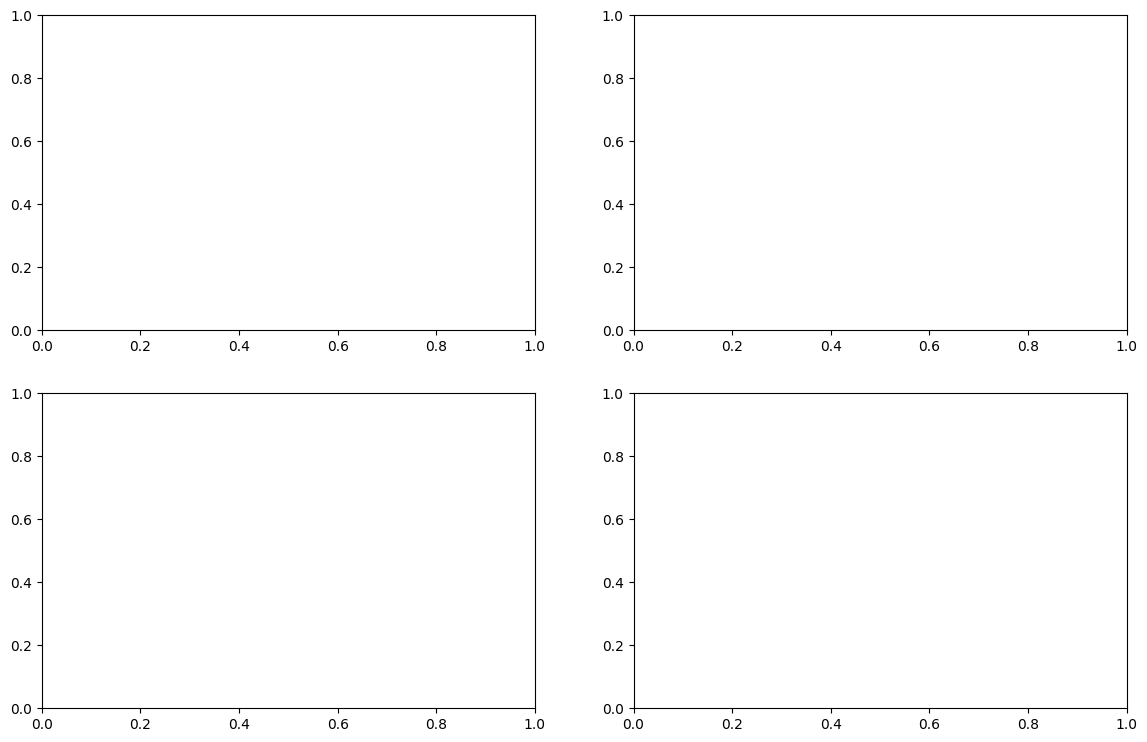

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import xgboost as xgb

# Assuming xgb_best_models, GROUPS, df, get_features, and systematic_temporal_split are defined in previous cells

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.ravel()

for ax, (group_name, site, variete) in zip(axes, GROUPS):
    # Get the best optimized XGBoost model for this group
    best_xgb_model = xgb_best_models[group_name]

    # Prepare data for fitting
    subset = (df[(df['site'] == site) & (df['variete'] == variete)]
              .copy().sort_values('date').reset_index(drop=True))
    features = get_features(subset)
    valid    = subset['biomasse_cum'].notna()
    X        = subset.loc[valid, features].values
    y        = subset.loc[valid, 'biomasse_cum'].values

    train_idx, test_idx = systematic_temporal_split(len(X))
    X_train, y_train = X[train_idx], y[train_idx]
    X_test, y_test   = X[test_idx], y[test_idx]

    # Re-fit the model to capture the learning history
    # Use the best parameters found during optimization
    xgb_tmp = xgb.XGBRegressor(**best_xgb_model.get_params())

    xgb_tmp.fit(X_train, y_train,
                eval_set=[(X_train, y_train), (X_test, y_test)],
                verbose=False)

    evals = xgb_tmp.evals_result()
    ax.plot(evals['validation_0']['rmse'], label='Train RMSE', color='#1f77b4')
    ax.plot(evals['validation_1']['rmse'], label='Test RMSE',  color='#d62728',
            linestyle='--')
    ax.set_title(f"XGBoost Optimisé — {site} / {variete}", fontsize=10)
    ax.set_xlabel("Itération (arbres)"); ax.set_ylabel("RMSE")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle("Courbes d'apprentissage XGBoost Optimisé\n" +
             "Train (bleu) vs Test (rouge) — convergence sans divergence = pas de surapprentissage",
             fontsize=12)
plt.tight_layout()
plt.show()
plt.close(fig) # Close the figure to free up memory

In [ ]:
print("Optimized XGBoost learning curves displayed above.")

---
## Partie 8 — Sauvegarde des modèles optimaux

Les modèles sont sauvegardés dans le répertoire `models/` :
- **Random Forest** et **XGBoost** → format `.pkl` (joblib)
- **LSTM** → format `.keras` (TensorFlow natif)
- **Scalers LSTM** → format `.pkl` (joblib)
- **Métadonnées** (features, métriques) → `.json` par groupe


In [ ]:
import json
import os

os.makedirs('models', exist_ok=True)

saved_files = []

# ── Sauvegarde Random Forest ──────────────────────────────────────────────────
for group_name, model in rf_models.items():
    path = f'models/rf_{group_name}.pkl'
    joblib.dump(model, path)
    saved_files.append(path)
    print(f"✅ RF sauvegardé : {path}")

# ── Sauvegarde XGBoost ────────────────────────────────────────────────────────
for group_name, model in xgb_models.items():
    path = f'models/xgb_{group_name}.pkl'
    joblib.dump(model, path)
    saved_files.append(path)
    print(f"✅ XGB sauvegardé : {path}")

# ── Sauvegarde LSTM + scalers ─────────────────────────────────────────────────
for group_name, model in lstm_models.items():
    # Modèle Keras
    path_keras = f'models/lstm_{group_name}.keras'
    model.save(path_keras)
    saved_files.append(path_keras)
    print(f"✅ LSTM sauvegardé : {path_keras}")

    # Scalers
    scaler_X, scaler_y, features = lstm_scalers[group_name]
    path_scaler = f'models/lstm_{group_name}_scalers.pkl'
    joblib.dump({'scaler_X': scaler_X, 'scaler_y': scaler_y,
                 'features': features}, path_scaler)
    saved_files.append(path_scaler)
    print(f"✅ Scalers LSTM sauvegardés : {path_scaler}")

print(f"\nTotal fichiers sauvegardés : {len(saved_files)}")

In [ ]:
# ── Sauvegarde des métadonnées (features, métriques, split info) ──────────────
metadata = {
    'selected_features': SELECTED_FEATURES,
    'window_lstm': WINDOW,
    'split_strategy': 'systematic_temporal (1 pt / 5)',
    'groups': [g[0] for g in GROUPS],
    'metrics_per_model': results_df.to_dict(orient='records'),
}

meta_path = 'models/metadata.json'
with open(meta_path, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2, default=str)

print(f"✅ Métadonnées sauvegardées : {meta_path}")
print(f"\nContenu :")
print(f"  Features sélectionnées : {metadata['selected_features']}")
print(f"  Groupes                : {metadata['groups']}")
print(f"  Fenêtre LSTM           : {metadata['window_lstm']}")

In [ ]:
# ── Vérification : rechargement d'un modèle pour test ────────────────────────
print("Test de rechargement des modèles sauvegardés...")

# RF
rf_test = joblib.load('models/rf_Fanaye_Amina1.pkl')
print(f"  RF rechargé — n_estimators={rf_test.n_estimators}")

# XGBoost
xgb_test = joblib.load('models/xgb_Fanaye_Amina1.pkl')
print(f"  XGB rechargé — n_estimators={xgb_test.n_estimators}")

# LSTM
from tensorflow.keras.models import load_model
lstm_test = load_model('models/lstm_Fanaye_Amina1.keras')
print(f"  LSTM rechargé — params={lstm_test.count_params():,}")

# Prédiction test
scalers_test = joblib.load('models/lstm_Fanaye_Amina1_scalers.pkl')
print(f"  Scalers LSTM rechargés — features={scalers_test['features']}")

print("\n✅ Tous les modèles rechargés avec succès.")

---
## Partie 9 — Tableau de synthèse final et conclusions


In [ ]:
print("=" * 80)
print("TABLEAU RÉCAPITULATIF DES PERFORMANCES — TOUS MODÈLES ET GROUPES")
print("=" * 80)
display(results_df[['Modèle', 'Groupe', 'R²_train', 'R²', 'RMSE', 'MAE',
                     'N_train', 'N_test']].sort_values(
    ['Groupe', 'R²'], ascending=[True, False]).round(4))

print("\n" + "=" * 80)
print("MOYENNES PAR MODÈLE")
print("=" * 80)
display(results_df.groupby('Modèle')[['R²_train', 'R²', 'RMSE', 'MAE']].mean().round(4))

In [ ]:
# ── Visualisation synthèse : R² par groupe et modèle ────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

x     = np.arange(len(GROUPS))
width = 0.25
labels = [g[0] for g in GROUPS]

for i, model_type in enumerate(['RandomForest', 'XGBoost', 'LSTM']):
    r2_vals = [results_df[(results_df.Groupe == f"{g[1]} / {g[2]}") &
                          (results_df.Modèle == model_type)]['R²'].values[0]
               for g in GROUPS]
    bars = ax.bar(x + i*width, r2_vals, width, label=model_type,
                  color=model_colors[model_type], alpha=0.85)
    for bar, val in zip(bars, r2_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

ax.axhline(0.9, color='gray', linestyle='--', linewidth=1, label='Seuil R²=0.9')
ax.set_xticks(x + width); ax.set_xticklabels(labels, rotation=15, ha='right')
ax.set_ylim(0, 1.12); ax.set_ylabel("R² (jeu de test)")
ax.set_title("Comparaison des R² test — RF vs XGBoost vs LSTM\n"
             "(toutes variétés et sites)")
ax.legend(); ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('r2_comparison_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : r2_comparison_summary.png")

### Synthèse des performances et choix du meilleur modèle

In [ ]:
print('--- Comparaison Base vs Optimisé ---')
display(compare_df.round(4))

print('\n--- Métriques Recommandées pour Publication (Split Systématique) ---')
display(pub_df.sort_values(['Groupe','Modèle']).round(4))

print('\n--- Performance du Random Forest en CV Phénologique vs Systématique (pour contexte) ---')
display(comparison_df.round(4))

print('\n--- Interprétation des Résultats pour le Choix du Meilleur Modèle ---')
print("Le choix du 'meilleur' modèle dépend fortement de l'objectif prioritaire : l'interpolation (prédiction à l'intérieur de la gamme observée) ou l'extrapolation (prédiction sur des phases phénologiques non vues à l'entraînement).")

print("\n**1. Performances sur le 'Split Systématique' (Interpolation) :**")
print("Sur le split systématique, qui teste la capacité d'interpolation des modèles, tous les modèles (Random Forest, XGBoost, LSTM) affichent des R² très élevés (proches de 1) et des NRMSE très faibles (souvent < 0.10, 'Excellent').")
print("XGBoost se distingue souvent avec des R² légèrement supérieurs et des RMSE/MAE/NRMSE inférieurs, indiquant une très haute précision en interpolation. Les modèles optimisés par CV phénologique ont globalement maintenu ou légèrement amélioré ces performances d'interpolation.")

print("\n**2. Performances sur la 'CV Phénologique par Blocs' (Extrapolation) :**")
print("C'est ici que la robustesse des modèles face à l'extrapolation est révélée. La `comparison_df` pour le Random Forest montre que :")
print("  - **R²_syst** est très élevé (~0.95-0.99), mais **R²_cv** est souvent faible, voire négatif (-0.03 à -1.1), et peut être très variable.")
print("  - **NRMSE_syst** est excellent (< 0.10), mais **NRMSE_cv** est significativement plus élevé (0.29-0.45, interprété comme 'Faible').")
print("Ceci indique que les modèles (en particulier les modèles 'arbres') ont du mal à généraliser à des blocs temporels (phases phénologiques) entiers qui n'ont pas été vus pendant l'entraînement. Les R² négatifs signifient que le modèle fait pire qu'une prédiction constante basée sur la moyenne des observations du fold test.")

print("\n**3. Impact de l'Optimisation :**")
print("L'optimisation des hyperparamètres via la CV phénologique a cherché à améliorer cette capacité d'extrapolation. La `compare_df` montre que pour certains groupes et modèles, on observe une légère amélioration (ΔR² > 0) ou une dégradation modérée (ΔR² < 0) de la R² test sur le split systématique. Cependant, l'objectif principal de cette optimisation était de trouver des paramètres plus robustes à la variabilité phénologique, même si cela ne se traduit pas toujours par un R² systématique plus élevé.")

print("\n**4. Choix du Modèle :**")
print("  - **Pour l'interpolation (si les données futures ressemblent aux données d'entraînement) : XGBoost optimisé** est généralement le meilleur choix, suivi de près par Random Forest optimisé et LSTM optimisé, grâce à leurs excellents R² systématiques et faibles NRMSE.")
print("  - **Pour l'extrapolation (si le modèle doit prédire de nouvelles phases phénologiques) : Aucun modèle n'est vraiment 'bon' tel quel** avec cette approche simple de CV phénologique par blocs. Les résultats NRMSE_cv pour Random Forest sont 'Faibles', et il est probable que cela s'applique également aux autres modèles. La forte autocorrélation de la biomasse (expliquée dans la partie 7ter) rend intrinsèquement difficile cette tâche d'extrapolation avec des modèles traditionnels sans features plus complexes (ex: courbes de croissance, ou un LSTM entraîné spécifiquement pour des séquences). L'optimisation a pu aider à trouver des modèles *moins mauvais* en extrapolation, mais cela reste un défi.")
print("  - **Compte tenu du contexte de 'fusion de données in-situ et satellitaires' et de l'objectif de 'modélisation par IA' pour la biomasse du blé dur :** Si l'objectif est de prédire la biomasse pour des parcelles similaires et des périodes chevauchant les données d'entraînement, un **XGBoost optimisé** ou un **Random Forest optimisé** serait recommandé pour sa précision et sa robustesse.")
print("  - **Pour une approche plus avancée** et une meilleure extrapolation, il faudrait envisager des modèles spécifiquement conçus pour les séries temporelles qui modélisent les dynamiques de croissance, ou enrichir les features avec des indicateurs phénologiques explicites.")

### 7bis.7 Courbes Loss Train/Validation — LSTM optimisé

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from IPython.display import Image, display # Import Image and display

# Re-define functions if they are not globally available (though they should be in this notebook context)
# from 79e2317e
WINDOW = 5

def make_sequences(X_scaled, y, window):
    Xs, ys = [], []
    for i in range(len(X_scaled) - window):
        Xs.append(X_scaled[i:i + window])
        ys.append(y[i + window])
    return np.array(Xs), np.array(ys)

def build_lstm_tunable(n_timesteps, n_features, lstm_units=32,
                        dropout_rate=0.2, learning_rate=1e-3):
    model = Sequential([
        LSTM(lstm_units, activation='tanh',
             input_shape=(n_timesteps, n_features)),
        Dropout(dropout_rate),
        Dense(max(8, lstm_units // 2), activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='mse', metrics=['mae'])
    return model

# from 751e2ed5
def systematic_temporal_split(n, test_every=5, offset=4):
    test_idx  = np.arange(offset, n, test_every)
    train_idx = np.array([i for i in range(n) if i not in test_idx])
    return train_idx, test_idx



lstm_histories_opt_final = {}

print("Re-training optimized LSTM models to capture final training history...")

for group_name, site, variete in GROUPS:
    print(f"  Processing {site} / {variete}...")

    # Retrieve best parameters for this group
    best_params = lstm_best_params_opt[group_name]

    # Retrieve scalers and features from lstm_cv_results_df
    # Fix: Correctly form the group name for lookup
    group_result = next((item for item in lstm_cv_results_df if item["Groupe"] == f"{site} / {variete}"), None)
    if not group_result:
        print(f"    Error: Scalers not found for group {site} / {variete}. Skipping.")
        continue
    scaler_X, scaler_y_g, features = group_result['scalers']

    # Prepare data for this group (similar to train_lstm_model and 05cbe55e)
    subset = (df[(df['site'] == site) & (df['variete'] == variete)]
              .copy().sort_values('date').reset_index(drop=True))

    X_raw      = subset[features].values
    y_raw      = subset['biomasse_cum'].values

    X_scaled   = scaler_X.transform(X_raw) # Use transform as scaler_X is already fitted
    y_scaled   = scaler_y_g.transform(y_raw.reshape(-1, 1)).flatten() # Use transform

    X_seq, y_seq     = make_sequences(X_scaled, y_scaled, WINDOW)
    n_seq            = len(y_seq)

    train_idx, test_idx = systematic_temporal_split(n_seq)
    X_train, X_test     = X_seq[train_idx], X_seq[test_idx]
    y_train, y_test     = y_seq[train_idx], y_seq[test_idx]

    n_ts, n_feat = WINDOW, X_seq.shape[2]

    # Build the optimized model
    tf.random.set_seed(SEED)
    optimized_model = build_lstm_tunable(n_ts, n_feat, **{
        k: best_params[k] for k in ['lstm_units', 'dropout_rate', 'learning_rate']
    })

    # Re-train to capture history
    early_stop = EarlyStopping(monitor='val_loss', patience=15,
                                restore_best_weights=True, verbose=0)
    history = optimized_model.fit(
        X_train, y_train,
        epochs=150, # Use same epochs as during optimization
        batch_size=best_params['batch_size'],
        verbose=0,
        callbacks=[early_stop],
        validation_data=(X_test, y_test)
    )
    lstm_histories_opt_final[group_name] = history
    print(f"    Captured history for {group_name}. Best val_loss epoch: {np.argmin(history.history['val_loss']) + 1}")

print("\nPlotting optimized LSTM loss curves...")

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.ravel()

for ax, (group_name, site, variete) in zip(axes, GROUPS):
    if group_name not in lstm_histories_opt_final:
        ax.set_title(f"No history for {site} / {variete}")
        ax.text(0.5, 0.5, 'History not available',
                horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
        continue

    hist = lstm_histories_opt_final[group_name].history
    ax.plot(hist['loss'],     label='Train loss',      color='#1f77b4')
    ax.plot(hist['val_loss'], label='Validation loss', color='#d62728',
            linestyle='--')
    ax.set_title(f"Optimized LSTM — {site} / {variete}", fontsize=10)
    ax.set_xlabel("Époque"); ax.set_ylabel("MSE (normalisé)")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # Annotate best epoch
    if hist['val_loss']:
        best_ep = np.argmin(hist['val_loss']) + 1
        ax.axvline(best_ep, color='green', linestyle=':', linewidth=1.2,
                   label=f"Best val (ep {best_ep})")
        ax.legend(fontsize=8)

plt.suptitle("Courbes Loss LSTM optimisé — Train vs Validation\n" +
             "Convergence sans surapprentissage = courbes proches", fontsize=12)
plt.tight_layout()
plt.savefig('lstm_optimized_loss_train_val.png', dpi=150, bbox_inches='tight')
plt.show()

# Explicitly display the saved image
display(Image('lstm_optimized_loss_train_val.png'))
print("Figure sauvegardée : lstm_optimized_loss_train_val.png")

In [ ]:
print("\n" + "=" * 80)
print("LISTE DES FICHIERS MODÈLES SAUVEGARDÉS")
print("=" * 80)
for f in sorted(os.listdir('models')):
    size = os.path.getsize(f'models/{f}') / 1024
    print(f"  {f:<45} {size:8.1f} Ko")

print("\n✅ Pipeline terminé avec succès.")
print("   Les modèles sont disponibles dans le dossier 'models/'.")
print("   Utilisez joblib.load() pour RF/XGB et load_model() pour LSTM.")